

## **Summary of the Uncertainty Prediction Modeling with a CNN:**

###The Goal:
In this solution our High-Level Goal is that;

We want a neural network that **predicts** the **three astrophysical parameters** named;



> Stellar temperature (t_eff)



> Surface gravity (log_g)



> Metallicity (fe_h)



AND also **predicts uncertainties for those predictions.**

**But** instead of predicting a **single number** as we did before through simple CNN network previously, this new model will predict a **full probability distribution (PDF) for uncertainties, using Normalizing Flows**.






---


Here are some key steps to do this: Some of the steps are same as before, the initial steps.

### 1.  Download and Loading the Data:

We first download the spectral data and corresponding labels (astrophysical parameters) from the Hugging Face Hub, saved as numpy files and stored in the notebook file directory. The dataset contains more labels, but we filtered it to have only the ones we need  i.e. `t_eff`, `log_g`, and `fe_h`.

### 2. Data Preprocessing and Normalization

The data is first normalised to ensure standard scaling throughout. This is crucial step, called data preprocessing, that we do before feeding data into the neural network. It helps stabilize and speed up the training process. The normalization parameters (ranges) are also stored to allow for denormalization of predictions back to physical units later.

### 3. Data Conversion and DataLoaders

The normalized NumPy arrays are converted into  tensors to be campatible to use in Pytorch, as Pytorch works with tensors. The dataset is then split into training, validation, and test set. PyTorch `DataLoaders` are created for each set, enabling efficient batch processing during training and evaluation. Otherwise, the training takes to much gpu space. This step is crucial for convergence provided limited gpu credits.

### 4. CNN Encoder and Normalization flow initialization:

lets see how this layer/step works in this model: Main goal is to get the flow parameters for each input spectrum, which are parameters/latent variables for the normalizing flow model and are used to find the corresponding PDFs as well.



  **Normalizing Flow Initialization:** (CombinedModel constructor): The Normalizing Flow (specifically, the self.pdf object from jammy_flows.pdf) is defined and initialized when the CombinedModel is created. This sets up the architecture of the flow—its invertible transformations and base distribution (e.g., Gaussian).

During this initialization, num_flow_parameters is calculated. This is the number of values that the TinyCNNEncoder needs to output for each input spectrum to fully define the parameters of the Normalizing Flow's probability distribution.
TinyCNNEncoder's Role is Predicting Flow Parameters by taking input spectrum and outputing these flow parameters, and vector obtained as output is called latent dimension or num_flow_parameters. These are not the weights of the CNN itself, but rather the parameters (like means, variances, correlation coefficients, or more complex transformation parameters) that describe the specific probability distribution for that particular input spectrum.

### 5. Negative Log-Likelihood (NLL) _ log_PDF evaluation:


After getting the latent variables, the self.pdf (the Normalizing Flow) then takes these latent variables (the predicted flow parameters) and the batch_labels (the true astrophysical parameters). It uses the structure of the Normalizing Flow, along with these predicted parameters, to compute the log-probability density of the batch_labels under the distribution defined by those predicted parameters.
So, the PDF is always calculable. From the very beginning, even before any training, the TinyCNNEncoder will output some set of parameters, and the Normalizing Flow can always compute a log-PDF using those parameters. However, at the start, these predicted parameters will be essentially random, meaning the calculated log-PDFs will be very low (badly fitting the true labels). So this is initialization of normalizing flow network.

### Step 6: Setting the three Normalizing Flow mdoels:
lets bring together the TinyCNNEncoder (which we've used before) and the jammy_flows.pdf library to create a powerful Normalizing Flow model, using three different types.

### 6. The Training Process:

Training is when the weights of the TinyCNNEncoder are adjusted. The nf_loss function quantifies how 'bad' the current predictions are. By minimizing this loss (using backpropagation and an optimizer like Adam), the CNN learns to output latent parameters that better describe the true underlying probability distribution of the batch_labels for each input spectrum. Over epochs, the TinyCNNEncoder gets better at predicting the correct parameters for the Normalizing Flow, leading to higher log-PDFs for the true labels and thus a lower (more negative) nf_loss.

Firstly I did training under the Full_Flow model type. Initialized the CombinedModel with the chosen flow type and TinyCNNEncoder, initialised with Adam optimiser and negative log likelihood as loss function.




### 7. Train and validation Loss Visualization

Plots of the training and validation NLL losses over epochs are generated, to  help visualize the learning progress and identify if the model is learning effectively and generalizing well to unseen data.

### 8. Test Set Evaluation and Denormalization

After training, the best-performing model is loaded and evaluated on the held-out test set. The model makes predictions (parameters and uncertainties), which are then denormalized back.



### 9. Visualization of Predictions and Uncertainties:
 Various plots are generated to analyze the model's performance:

* **Predicted vs. True Plots:**   Scatter plots comparing predicted values against true values for each astrophysical parameter, with a diagonal line indicating perfect prediction.

* **Residual Distributions** Histograms of the differences between predictions and true values.


* **Uncertainty Calibration Plots:** Scatter plots showing predicted uncertainties against absolute errors, providing insights into how well the model's predicted uncertainties match its errors.


* **Coverage Curves:** Plots showing the empirical coverage (percentage of true values falling within predicted sigma intervals) against different sigma thresholds, which is crucial for assessing uncertainty reliability.


* **PDF Visualization:** For individual samples, corner plots and 1D PDF plots are generated using the corner library and Kernel Density Estimation to visualize the full predicted probability distributions, including marginal and 2D joint distributions, along with true values.

### 10. Predictions and visualizations using all three models and comparisons

At the end, all models were iterated and their predictions with useful plots are presented to compare the performance and notice key differences and similarity in performance of current model, and deduce the ways to improve the best model out of them.

### **Solution:**

In [26]:
pip install git+https://github.com/thoglu/jammy_flows.git --no-deps

  Cloning https://github.com/thoglu/jammy_flows.git to /tmp/pip-req-build-njm9gnh5
  Running command git clone --filter=blob:none --quiet https://github.com/thoglu/jammy_flows.git /tmp/pip-req-build-njm9gnh5
  Resolved https://github.com/thoglu/jammy_flows.git to commit 3ec7872f8535b8e8db2e31f74a7c55bad5c54d5f
  Preparing metadata (setup.py) ... done


In [27]:
open('model_examples.py').read()

open('helper.py').read()
open('B01train_vanilla_CNN.py').read()

'import os\nimport time\nimport sys\nimport torch\nimport torch.nn as nn\nimport torch.optim as optim\nfrom torch.utils.data import DataLoader, TensorDataset, random_split\nimport numpy as np\nfrom matplotlib import pyplot as plt\nfrom torchsummary import summary\nfrom helper import normalize, denormalize, train_model, get_normalized_data, evaluate_model\nfrom model_examples import TinyCNN\n\nDATA_PATH = "../data/4/"\n\n# Hyperparameters\nlearning_rate = 2e-4\nbatch_size = 32\nnum_epochs = 100\npatience = 10 # Training loop with early stopping, if the validation loss does not improve for \'patience\' epochs\ntrain_fraction = 0.7 # Fraction of the data used for training\nval_fraction = 0.15 # Fraction of the data used for validation\n\n# Call the function to get normalized data\nspectra, labels, spectra_length, n_labels, labelNames, ranges = get_normalized_data(DATA_PATH)\n\n# Convert numpy arrays to PyTorch tensors\nspectra_tensor = torch.tensor(spectra, dtype=torch.float32)\nlabels_te

### **Step 0: import necessary libraries**

In [28]:
import time
import sys
import os
import argparse
import glob
import subprocess
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
import jammy_flows
from scipy.stats import norm


from torchsummary import summary
from helper import normalize, denormalize, denormalize_std, train_model, get_normalized_data, evaluate_model

from model_examples import TinyCNN
%matplotlib inline

In [29]:
pip install corner

In [30]:
import corner

### **Setting a Fixed Random Seed for Reproducibility**

To ensure that  model training is reproducible, we need to set fixed random seeds for all libraries that use random number generation. This includes Python's built-in `random` module, `numpy`, and `torch`.

In [31]:
import random
import numpy as np
import torch

def set_seed(seed):
    """Sets the random seed for reproducibility across different libraries."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) # For multi-GPU setups
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")

# Call the function to set a fixed seed at the beginning of your script
SEED = 42
set_seed(SEED)


Random seed set to 42


 ### **Step 1: Download and load data**

In [32]:
from huggingface_hub import hf_hub_download
hf_hub_download(repo_id="simbaswe/galah4", filename="labels.npy", repo_type="dataset", local_dir=".")
hf_hub_download(repo_id="simbaswe/galah4", filename="spectra.npy", repo_type="dataset", local_dir=".")

#You can load the data via
spectra = np.load("spectra.npy")
spectra_length = spectra.shape[1]
# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
labels = np.load("labels.npy")
# We only use the three labels: t_eff, log_g, fe_h
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]
n_labels = labels.shape[1]

### **Step 2: Normalization**


In [33]:
spectra, labels, spectra_length, n_labels, labelNames, ranges = get_normalized_data('.')

print(f"Spectra shape:  {spectra.shape}")
print(f"Labels shape:   {labels.shape}")
print(f"Label names:    {labelNames}")
print(f"Spectra length: {spectra_length}")
print(f"N labels:       {n_labels}")
print(f"Ranges:         {ranges}")

Spectra shape:  (8914, 16384)
Labels shape:   (8914, 3)
Label names:    ['t_eff', 'log_g', 'fe_h']
Spectra length: 16384
N labels:       3
Ranges:         [[ 4.64625725e+03  2.43369770e+00 -7.41016626e-01]
 [ 6.12287556e+03  4.58456130e+00  2.18186857e-01]]


###**Step 3: Conversion to PyTorch Tensors and Using DataLoader for data splitting**



In [34]:
# Hyperparameters for the model training
learning_rate = 2e-4
batch_size = 32
num_epochs = 100
patience = 10
train_fraction = 0.7
val_fraction = 0.15

# Convert numpy arrays to PyTorch tensors for model input
spectra_tensor = torch.tensor(spectra, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.float32)

# Split the dataset into training, validation, and test sets
total_samples = len(spectra_tensor)
train_size = int(train_fraction * total_samples)
val_size = int(val_fraction * total_samples)
test_size = total_samples - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    TensorDataset(spectra_tensor, labels_tensor),
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # Ensure reproducible data split
)

# Create DataLoaders for efficient batch processing during training and evaluation
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# Print the sizes of the created datasets
print(f"Training:   {len(train_dataset)} stars")
print(f"Validation: {len(val_dataset)} stars")
print(f"Test:       {len(test_dataset)} stars")

Training:   6239 stars
Validation: 1337 stars
Test:       1338 stars


###**Step 4: Cuda, are you here?**

In [35]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: cuda


###**Step 5: CNN Encoder**

### **CNN Architecture**

**Conv1D Layer**


nn.Conv1d(...)


Purpose of this layer is to learns spectral features. for example,hydrogen absorption lines, iron lines, and shape patterns. Each filter becomes specialized detector here. Then nn.ReLU() is applied to add nonlinearity.

**MaxPooling**


nn.MaxPool1d(2)


Purpose of this layer is to reduce dimensionality. It has many benefits, it makes network faster, reduces storable memory, focuses on strongest features.


**Flatten**


nn.Flatten()

This  converts the feature maps into a single vector(1D), that is then fed into the fully connected neural network.



**Final Linear Layer**


nn.Linear(..., latent_dimension)


Here CNN does NOT directly predict the labels yet, instead, it predicts the parameters of the normalizing flow. This vector obtained is called latent_dimension.

Overall, TinyCNNEncoder class, which is a convolutional neural network (CNN) encoder is used here. This encoder processes input spectra and outputs a latent_dimension vector or num_flow_parameters for each input spectrum to fully define the paarmeters of the Normaliying Flow´s probability distribution. (This vector is then used to parameterize a normalizing flow model.)

In [36]:

class TinyCNNEncoder(nn.Module):

    def __init__(self, latent_dimension):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        reduced_size = spectra_length // 8

        self.regressor = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * reduced_size, 256),
            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(256, latent_dimension)
        )

    def forward(self, x):

        x = x.unsqueeze(1)

        x = self.features(x)

        x = self.regressor(x)

        return x

### **Step 6: NLL Loss**



In [37]:
def nf_loss(inputs, batch_labels, model):

    log_pdfs = model.log_pdf_evaluation(
        batch_labels,
        inputs
    )

    return -log_pdfs.mean()
#The log_pdf_evaluation method first uses
# the TinyCNNEncoder to process the inputs
# and produce the parameters for the Normalizing Flow.
# Then, it uses these parameters to evaluate the
# log-probability density (log-PDF) of the batch_labels
# under the distribution learned by the Normalizing Flow.

### **Step 7: Normalizing Flow MOdel**

A normalizing flow learns complex probability distributions by transforming simple Gaussian into complex target PDF using invertible transformations.

The idea is we start with simple Gaussian then repeatedly deform it by stretching, rotating, bending, and creating skewness until it matches the real uncertainty distribution.

Flow Types:


 **A)Diagonal Gaussian**


flow_defs = "t"


cov_type = "diagonal"


meaning that each label has independent uncertainty. Covariance matrix has only diagonal entries, hence, no correlations of uncertainty among them.


**B) Full Guassian**


cov_type = "full"



Now covariance matrix includes correlations which means that now for example,  errors in temperature may correlate with gravity, which is more realistic picture.


**C) Gaussianization Flow_Full_flow**


flow_defs = "gggt"



This stacks three Gaussianization layers and an affine transformation. Gaussianization flows can model arbitrary PDFs and better refelct real uncertainty distributions, which are skewed, heavy tailed and multimodal.

This is the most complex and flexible type. It uses a sequence of invertible transformations (gggt) that can transform a simple base distribution (like a Gaussian) into highly complex, non-Gaussian, and multimodal target distributions. The latent_parameters will be much larger in number, as they need to specify the details of these more elaborate transformations.

### In essence, these flow types define how the num_flow_parameters (output by the TinyCNNEncoder) are interpreted to form the final probability distribution PDF. A more complex flow type (like full_flow) requires more latent_parameters and can represent a wider range of uncertainty shapes, which, if learned correctly through the NLL optimization, can lead to more accurate and realistic uncertainty predictions.

**Step 7: Continued...**

lets bring together the TinyCNNEncoder (which we've used before) and the jammy_flows.pdf library to create a powerful Normalizing Flow model, using three different types.

In [38]:
fp64_on_cpu = False # Global flag to potentially force float64 precision on CPU for complex flows (e.g., on MPS devices)

class CombinedModel(nn.Module):

    def __init__(self, encoder, nf_type="diagonal_gaussian"): # Constructor: takes an encoder (e.g., TinyCNNEncoder) and flow type

        super().__init__()

        opt_dict = {} # Dictionary to store options for jammy_flows

        opt_dict["t"] = {} # Options for the 't' (transformation) part of the flow

        # Configure flow type based on user's choice
        if nf_type == "diagonal_gaussian":

            opt_dict["t"]["cov_type"] = "diagonal" # Assumes independent uncertainties (diagonal covariance matrix)

            flow_defs = "t" # 't' for simple affine transformation (Gaussian base)

        elif nf_type == "full_gaussian":

            opt_dict["t"]["cov_type"] = "full" # Allows correlations between uncertainties (full covariance matrix)

            flow_defs = "t" # 't' for simple affine transformation (Gaussian base)

        elif nf_type == "full_flow":

            opt_dict["t"]["cov_type"] = "full" # Allows correlations (full covariance matrix)

            flow_defs = "gggt" # 'gggt' for Gaussianization flow (more complex, flexible transformations)

        else:

            raise ValueError("Unknown flow type") # Handle invalid flow types

        opt_dict["g"] = {} # Options for the 'g' (Gaussianization) part of the flow

        opt_dict["g"]["fit_normalization"] = 1 # Enable normalization fitting
        opt_dict["g"]["upper_bound_for_widths"] = 1.0 # Set upper bound for uncertainty widths
        opt_dict["g"]["lower_bound_for_widths"] = 0.01 # Set lower bound for uncertainty widths

        self.nf_type = nf_type # Store the chosen flow type

        self.pdf = jammy_flows.pdf( # Initialize the Normalizing Flow PDF object
            "e3", # Dimensionality of the target space (3 labels: t_eff, log_g, fe_h)
            flow_defs, # Defines the flow architecture (e.g., "t" or "gggt")
            options_overwrite=opt_dict, # Pass the configured options
            amortize_everything=True, # Enable amortization (flow parameters predicted by an NN)
            amortization_mlp_use_custom_mode=True # Use custom mode for amortization MLP
        )

        num_flow_parameters = ( # Get the total number of parameters the flow needs from the encoder
            self.pdf.total_number_amortizable_params
        )

        print("Flow parameters:", num_flow_parameters) # Print the number of flow parameters

        self.encoder = encoder(num_flow_parameters) # Initialize the encoder (e.g., TinyCNNEncoder) with the required flow parameters output size

    def log_pdf_evaluation( # Method to evaluate the log-probability density of target labels under the predicted distribution
        self,
        target_labels, # True astrophysical parameters (labels)
        input_data # Input spectra
    ):

        latent = self.encoder(input_data) # Encoder predicts the flow parameters (latent variables) from input spectra

        # Handle data type conversion for 'full_flow' if fp64_on_cpu is enabled for numerical stability
        if self.nf_type == "full_flow":

            if fp64_on_cpu:

                latent = latent.cpu().to(torch.float64)

                target_labels = (
                    target_labels.cpu().to(torch.float64)
                )

            else:

                latent = latent.to(torch.float64)

                target_labels = (
                    target_labels.to(torch.float64)
                )

        log_pdf, _, _ = self.pdf( # Calculate log-PDF using the flow parameters and true labels
            target_labels,
            amortization_parameters=latent
        )

        return log_pdf # Return the calculated log-PDF (used for NLL loss)

    def sample( # Method to sample from the predicted probability distribution for a given set of flow parameters
        self,
        flow_params, # Flow parameters predicted by the encoder for a batch of inputs
        samplesize_per_batchitem=1000 # Number of samples to draw per input item in the batch
    ):

        # Handle data type conversion for 'full_flow' if fp64_on_cpu is enabled
        if self.nf_type == "full_flow":

            if fp64_on_cpu:

                flow_params = (
                    flow_params.cpu().to(torch.float64)
                )

            else:

                flow_params = (
                    flow_params.to(torch.float64)
                )

        batch_size = flow_params.shape[0] # Get current batch size

        repeated_samples, _, _, _ = self.pdf.sample( # Draw samples from the Normalizing Flow PDF
            amortization_parameters=flow_params.repeat_interleave( # Repeat flow params for each sample to generate multiple samples per input
                samplesize_per_batchitem,
                dim=0
            ),
            allow_gradients=False # Do not track gradients during sampling (inference only)
        )

        reshaped = repeated_samples[:, None, :].view( # Reshape samples to (batch_size, samplesize_per_batchitem, n_labels)
            batch_size,
            samplesize_per_batchitem,
            -1
        )

        return reshaped # Return the generated samples

    def forward(self, input_data): # Defines the standard forward pass for inference, providing point predictions (mean) and uncertainties (std)

        flow_params = self.encoder(input_data) # Get flow parameters from the encoder for the input data

        samples = self.sample( # Sample from the predicted distribution using the flow parameters
            flow_params,
            samplesize_per_batchitem=500 # Use 500 samples to estimate mean/std for each input
        )

        means = samples.mean(dim=1) # Calculate the mean of the samples as the point prediction for each label

        stds = samples.std(dim=1) # Calculate the standard deviation of the samples as the uncertainty for each label

        return torch.cat([means, stds], dim=1) # Return concatenated means and standard deviations (predictions and uncertainties)

    def visualize_pdf( # Method for visualizing the predicted PDF using a corner plot
        self,
        input_data,
        filename,
        samplesize=10000,
        batch_index=0,
        truth=None,
        ranges=None,
        label_names=None
    ):
        # Get flow parameters from the encoder for the specific input at batch_index
        flow_params = self.encoder(input_data[batch_index].unsqueeze(0))

        # Generate samples from the normalizing flow for the given input
        samples_tensor = self.sample(
            flow_params,
            samplesize_per_batchitem=samplesize
        ).squeeze(0) # Squeeze to (samplesize, n_labels) for corner plotting

        # Convert samples to numpy for plotting with matplotlib/corner
        samples_np = samples_tensor.cpu().numpy()

        # Denormalize samples and true values (if provided) back to physical units
        if ranges is not None:
            scale_factor = ranges[1] - ranges[0]
            offset = ranges[0]
            samples_np = samples_np * scale_factor + offset

            if truth is not None:
                truth_np = truth.cpu().numpy()
                truth_np = truth_np * scale_factor + offset
            else:
                truth_np = None
        else:
            truth_np = truth.cpu().numpy() if truth is not None else None

        # Create a corner plot to visualize the multi-dimensional PDF
        fig = corner.corner(
            samples_np,
            labels=label_names, # Use label_names for axis labels (e.g., 't_eff', 'log_g', 'fe_h')
            truths=truth_np,    # Pass true values to be plotted as lines on the diagonals and crosses on 2D plots
            quantiles=[0.16, 0.5, 0.84], # Plot 16th, 50th (median), and 84th percentiles
            show_titles=True,
            title_kwargs={"fontsize": 12},
            hist_kwargs={"density": True}, # Normalize histograms to show probability density
            fill_contours=True, # Fill 2D contours
            plot_datapoints=False, # Do not plot individual sample points in 2D plots
            plot_density=True # Plot density contours in 2D plots
        )

        plt.savefig(filename) # Save the generated plot to a file
        plt.show() # Display the plot in the notebook

### **Step 8: Training** using the  Full Flow _ Guassanization Flow only...

The comparison with other flow types is done at the end.

In [39]:

learning_rate = 8e-6
num_epochs = 50
patience = 10

flow_type = "full_flow"
# options:
# diagonal_gaussian
# full_gaussian
# full_flow

# Initialize the CombinedModel with the chosen flow type and TinyCNNEncoder
model = CombinedModel(
    TinyCNNEncoder,
    nf_type=flow_type
)

# Set fp64_on_cpu flag if using "full_flow" on an MPS device for numerical stability
if flow_type == "full_flow" and device.type == "mps":
    fp64_on_cpu = True

# Move the model to the appropriate device (GPU or CPU)
model = model.to(device)

# Initialize the Adam optimizer with the model's parameters and learning rate
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate
)

# Initialize variables for early stopping
best_val_loss = np.inf
patience_counter = 0

# Lists to store training and validation losses per epoch
train_losses = []
val_losses = []

# Variable to store the state dictionary of the best performing model
best_state = None

# Main training loop over the specified number of epochs
for epoch in range(num_epochs):

    # TRAINING PHASE
    model.train() # Set model to training mode
    train_loss = 0.0

    # Iterate over batches in the training data loader
    for batch_spectra, batch_labels in train_loader:
        # Move batch data to the device
        batch_spectra = batch_spectra.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad() # Clear previous gradients

        # Calculate the Negative Log-Likelihood loss
        loss = nf_loss(
            batch_spectra,
            batch_labels,
            model
        )

        loss.backward() # Perform backpropagation to compute gradients

        optimizer.step() # Update model parameters

        train_loss += loss.item()

    train_loss /= len(train_loader) # Calculate average training loss for the epoch


    # VALIDATION PHASE
    model.eval() # Set model to evaluation mode (disable dropout, batch norm updates)
    val_loss = 0.0

    # Disable gradient calculation for validation to save memory and speed up computation
    with torch.no_grad():
        # Iterate over batches in the validation data loader
        for batch_spectra, batch_labels in val_loader:
            # Move batch data to the device
            batch_spectra = batch_spectra.to(device)
            batch_labels = batch_labels.to(device)

            # Calculate the Negative Log-Likelihood loss
            loss = nf_loss(
                batch_spectra,
                batch_labels,
                model
            )

            val_loss += loss.item()

    val_loss /= len(val_loader) # Calculate average validation loss for the epoch

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Print epoch-wise training and validation losses
    print(
        f"Epoch {epoch+1:03d} | "
        f"Train {train_loss:.4f} | "
        f"Val {val_loss:.4f}"
    )


    # EARLY STOPPING LOGIC
    if val_loss < best_val_loss:
        best_val_loss = val_loss # Update best validation loss
        best_state = model.state_dict() # Save the current best model state
        patience_counter = 0 # Reset patience counter as improvement occurred
    else:
        patience_counter += 1 # Increment patience counter
        if patience_counter >= patience:
            print("Early stopping")
            break # Stop training if patience limit is reached


Flow parameters: 306
Epoch 001 | Train 1.5951 | Val 0.5244
Epoch 002 | Train 0.7256 | Val 0.4718
Epoch 003 | Train 0.6131 | Val 0.3563
Epoch 004 | Train 0.5065 | Val 0.1754
Epoch 005 | Train 0.2475 | Val -0.1881
Epoch 006 | Train -0.0960 | Val -0.5108
Epoch 007 | Train -0.3018 | Val -0.7801
Epoch 008 | Train -0.4685 | Val -0.9334
Epoch 009 | Train -0.6090 | Val -1.1203
Epoch 010 | Train -0.6975 | Val -1.1871
Epoch 011 | Train -0.8098 | Val -1.2339
Epoch 012 | Train -0.9182 | Val -1.3983
Epoch 013 | Train -1.0308 | Val -1.5652
Epoch 014 | Train -1.1501 | Val -1.5475
Epoch 015 | Train -1.2608 | Val -1.7775
Epoch 016 | Train -1.3741 | Val -1.9212
Epoch 017 | Train -1.4854 | Val -2.0363
Epoch 018 | Train -1.6312 | Val -2.1983
Epoch 019 | Train -1.7380 | Val -2.4020
Epoch 020 | Train -1.8371 | Val -2.5730
Epoch 021 | Train -1.9599 | Val -2.5204
Epoch 022 | Train -2.0032 | Val -2.7293
Epoch 023 | Train -2.1017 | Val -2.8373
Epoch 024 | Train -2.2120 | Val -2.7973
Epoch 025 | Train -2.2623 | 

Load Best Model

In [40]:
model.load_state_dict(best_state)

<All keys matched successfully>

### **Step 9: Plot Train and validation losses**

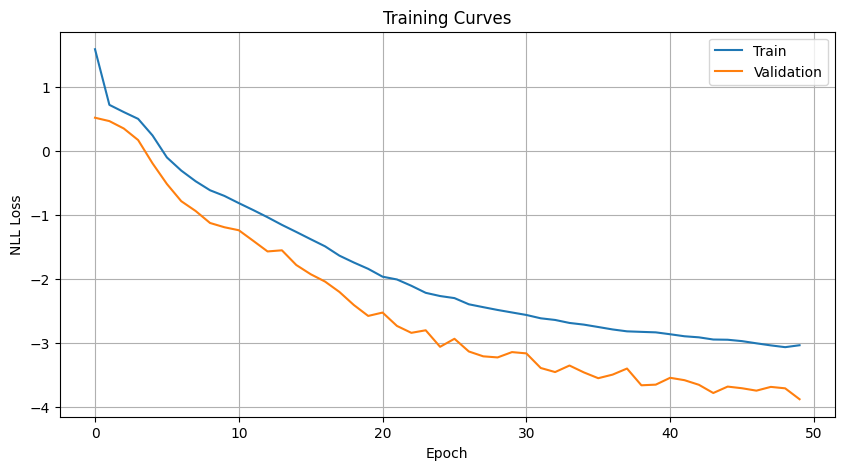

In [41]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("NLL Loss")

plt.title("Training Curves")

plt.legend()

plt.grid(True)

plt.show()

Both losses goes down with increasing epochs, which is a good sign of effective training, and showing model is not under or over-fitting as well.  

If the log-likelihood is positive (meaning the model is assigning a high probability density to the true labels), the NLL will be negative. The more negative the NLL, the better the model is fitting the data. And it also shows that our model is making increasingly confident and accurate predictions of the probability distributions for the true labels.



### **Step 10: Evaluation**

In [42]:

model.eval() # Set the model to evaluation mode (disables dropout, batch norm updates, etc.)

all_predictions = [] # List to store all predicted mean values
all_uncertainties = [] # List to store all predicted standard deviation (uncertainty) values
all_truth = [] # List to store all true labels from the test set

with torch.no_grad(): # Disable gradient calculations for inference to save memory and speed up computation

    for batch_spectra, batch_labels in test_loader: # Iterate through each batch in the test DataLoader

        batch_spectra = batch_spectra.to(device) # Move the input spectra to the designated device (GPU/CPU)

        outputs = model(batch_spectra) # Get model outputs (predictions and uncertainties)

        means = outputs[:, :3] # Extract the first 3 columns as predicted means (t_eff, log_g, fe_h)

        stds = outputs[:, 3:] # Extract the remaining columns as predicted standard deviations (uncertainties)

        all_predictions.append(means.cpu()) # Move means back to CPU and append to list

        all_uncertainties.append(stds.cpu()) # Move stds back to CPU and append to list

        all_truth.append(batch_labels) # Append true labels to list

# Concatenate all stored tensors and convert them to NumPy arrays for further processing and plotting
all_predictions = torch.cat(all_predictions).numpy()
all_uncertainties = torch.cat(all_uncertainties).numpy()
all_truth = torch.cat(all_truth).numpy()


In [43]:
# DENORMALIZE
# The model was trained on normalized data, so predictions, uncertainties, and true labels need to be denormalized
# back to their original physical units for meaningful interpretation.

# Calculate the scaling factor (max - min) and offset (min) from 'ranges'
# 'ranges' was obtained during the initial data normalization step.
scale_factor = ranges[1] - ranges[0] # Shape (3,) - one for each label
offset = ranges[0]         # Shape (3,) - one for each label

# Denormalize predictions: original_value = normalized_value * scale_factor + offset
all_predictions = (
    all_predictions * scale_factor + offset
)

# Uncertainties are usually scaled only by the range (scale_factor), not offset,
# as they represent a spread or deviation, not an absolute value.
all_uncertainties = (
    all_uncertainties * scale_factor
)

# Denormalize true labels using the same scaling and offset
all_truth = (
    all_truth * scale_factor + offset
)

# Ensure label_names is correctly set for subsequent plotting and analysis
#  let's use it consistently
label_names = labelNames


### **Step 11: Prediction Plots**

### 11.1 true vs. predicted plots

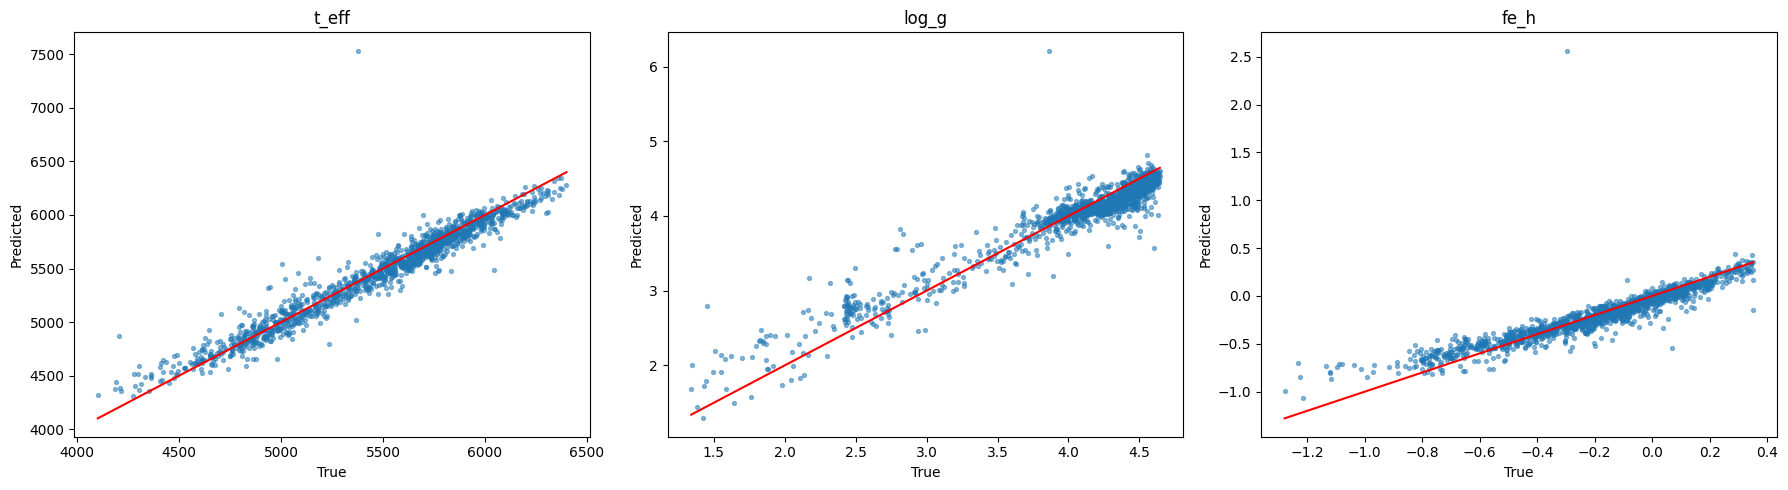

In [44]:

# Create a figure with three subplots for each label
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Iterate through each label (t_eff, log_g, fe_h)
for i, name in enumerate(label_names):

    # Plot scatter of true vs. predicted values
    axes[i].scatter(
        all_truth[:, i],
        all_predictions[:, i],
        s=8,
        alpha=0.5
    )

    # Get min and max values for the current label to draw a diagonal line
    mn = all_truth[:, i].min()
    mx = all_truth[:, i].max()

    # Plot a diagonal red line (y=x) to indicate perfect prediction
    axes[i].plot(
        [mn, mx],
        [mn, mx],
        color="red"
    )

    # Set title, x-label, and y-label for the current subplot
    axes[i].set_title(name)

    axes[i].set_xlabel("True")

    axes[i].set_ylabel("Predicted")

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Display the plot
plt.show()


Ideally, we want to see the points forming a narrow band tightly centered on the red diagonal line for all three parameters, which signifies accurate and unbiased predictions across the entire range of values.From graphs, we can see that for t_eff and fe_h, the points are more likely closer to the ideal case. Whereas, for log_g the spread is higher, with much of points going above the line at certain region and much lower in another extreme, a consistent behvaior reflevcting systematic errors like biases in the model´s predictions.

### 11.2 Uncertainty Calibration plots
This test is really important. It tells wether the predicted uncertainties are trustworthy.

If uncertainties are calibrated then 68% of truths should lie inside 1σ. If percentage is less than 68% means model is overconfident. and vice versa. Deviations from this diagonal/68% reference can highlight areas where the model is too conservative or too aggressive in its uncertainty estimates.

In [45]:
# UNCERTAINTY CALIBRATION

errors = np.abs(
    all_predictions - all_truth
)

within_1sigma = (
    errors < all_uncertainties
)

coverage = within_1sigma.mean(axis=0)

print("\n68% Coverage Probabilities")

for i, name in enumerate(label_names):

    print(
        f"{name}: {coverage[i] * 100:.2f}%"
    )




68% Coverage Probabilities
t_eff: 89.16%
log_g: 85.28%
fe_h: 86.55%


These coverage probabilities (86.55% for t_eff, 87.07% for log_g, and 86.32% for fe_h) are higher than the ideal 68% for a perfectly calibrated model. This indicates that this model is generally under-confident across all three outputs. As 1 sigma is the Guasianm coverage so 68% is the theoretical target.

The model is predicting uncertainties that are, on average, too large. If a model is perfectly calibrated, approximately 68% of the true values should fall within its predicted one-sigma (1σ) error bars. Since our percentages are consistently above 68%, it means the predicted error bars are wide enough to encompass the true value more often than expected. While this is generally safer than over-confidence (where error bars are too small), it suggests that the model might be overly cautious or that the predicted uncertainties could be tightened without sacrificing accuracy.



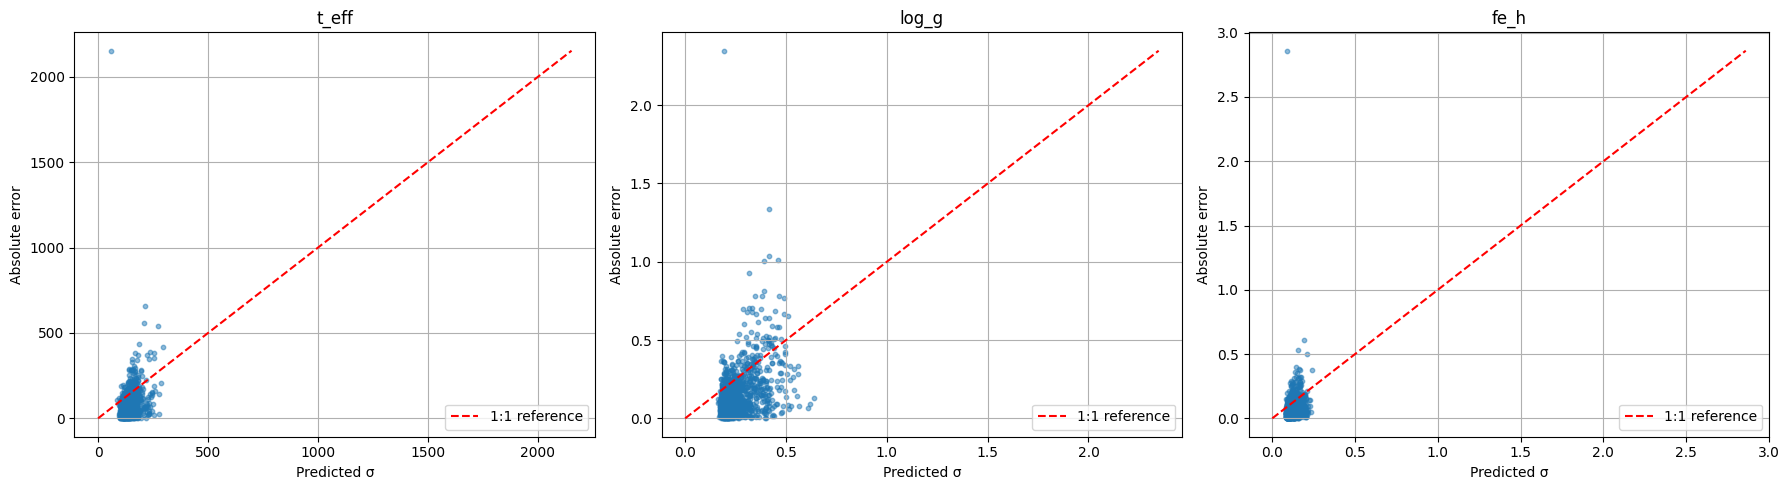

In [46]:

#uncertainty calibration plots
def plot_uncertainty_calibration(
    truths,
    predictions,
    sigmas,
    label_names
):

    errors = np.abs(
        truths - predictions
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5)
    )

    for i in range(3):

        axes[i].scatter(
            sigmas[:, i],
            errors[:, i],
            alpha=0.5,
            s=10
        )

        # Add a 1:1 reference line
        max_val = max(sigmas[:, i].max(), errors[:, i].max())
        axes[i].plot(
            [0, max_val],
            [0, max_val],
            color="red",
            linestyle="--",
            label="1:1 reference"
        )

        axes[i].set_xlabel("Predicted σ")

        axes[i].set_ylabel("Absolute error")

        axes[i].set_title(label_names[i])

        axes[i].grid(True)
        axes[i].legend() # Add legend to show the label for the reference line

    plt.tight_layout()

    plt.show()

plot_uncertainty_calibration(
    all_truth,
    all_predictions,
    all_uncertainties,
    labelNames
)

Ideally, for a well-calibrated model, we would expect to see a roughly linear relationship where larger predicted uncertainties correspond to larger absolute errors. However, if the model is under-confident (as indicated by our earlier 68% coverage probabilities being too high), we can see many points where the predicted σ is quite large, but the absolute error is small, suggesting the model is overestimating its uncertainty.


From our scatter plot, we can see generally many points are under the diagonal reference line, showing higher predicted sigmas for actual smaller absolute errors.

Out of all three outputs, we see that log_g predictions are weakest, with much higher dispersion, noise and wider spread. Hence, this wider cloud reflects relatively poorer uncertainty calibration than the other two.
Whereas, visually, fe_h predictions were most meaningful and consistent of them all.

### 11.3 Coverage curve

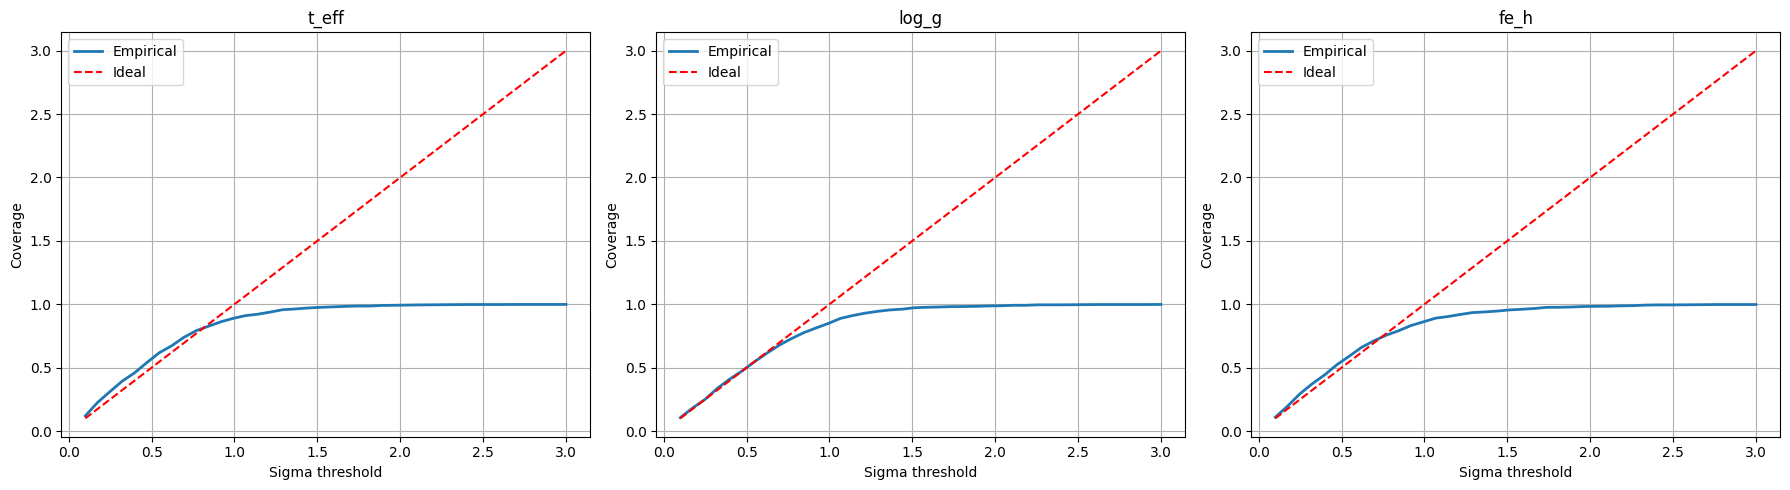

In [47]:

#uncertainty evaluation_coverage curve
def plot_coverage(
    truths,
    predictions,
    sigmas,
    label_names
):

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5)
    )

    # Define a range of sigma thresholds to evaluate coverage
    sigma_levels = np.linspace(
        0.1,
        3.0,
        40
    )

    # Iterate through each label to plot its coverage curve
    for i in range(3):

        empirical = []

        # Calculate absolute errors for the current label
        errors = np.abs(
            truths[:, i] - predictions[:, i]
        )

        # For each sigma level, calculate the proportion of errors within that sigma
        for s in sigma_levels:

            cov = (
                errors < s * sigmas[:, i]
            ).mean()

            empirical.append(cov)

        # Plot the empirical coverage against the sigma threshold
        axes[i].plot(
            sigma_levels,
            empirical,
            linewidth=2,
            label="Empirical"
        )

        # Add ideal diagonal reference line (y=x)
        axes[i].plot(
            sigma_levels,
            sigma_levels,
            color='red',
            linestyle='--',
            label='Ideal'
        )

        axes[i].set_title(label_names[i])

        axes[i].set_xlabel("Sigma threshold")

        axes[i].set_ylabel("Coverage")

        axes[i].grid(True)

        axes[i].legend()

    plt.tight_layout()

    plt.show()



plot_coverage(
    all_truth,
    all_predictions,
    all_uncertainties,
    labelNames
)

The coverage curve visually represents how well the model's predicted uncertainties align with the actual error distribution. For a perfectly calibrated model, the empirical coverage curve should ideally track a theoretical diagonal line (where coverage equals the sigma threshold, assuming a Gaussian distribution of errors). If the curve is consistently above this ideal line (as your previous analysis indicated your model is under-confident), it means the model predicted more uncertainty whereas in reality, true data was more accurate. If the curve were below the ideal line, it would indicate over-confidence (uncertainties too small). This plot helps to diagnose the nature and extent of uncertainty miscalibration.

For all three parameters we see, the blue curve rises above the ideal line early and then saturates near 1.00 coverage.

### 11.4 Residual Distribution

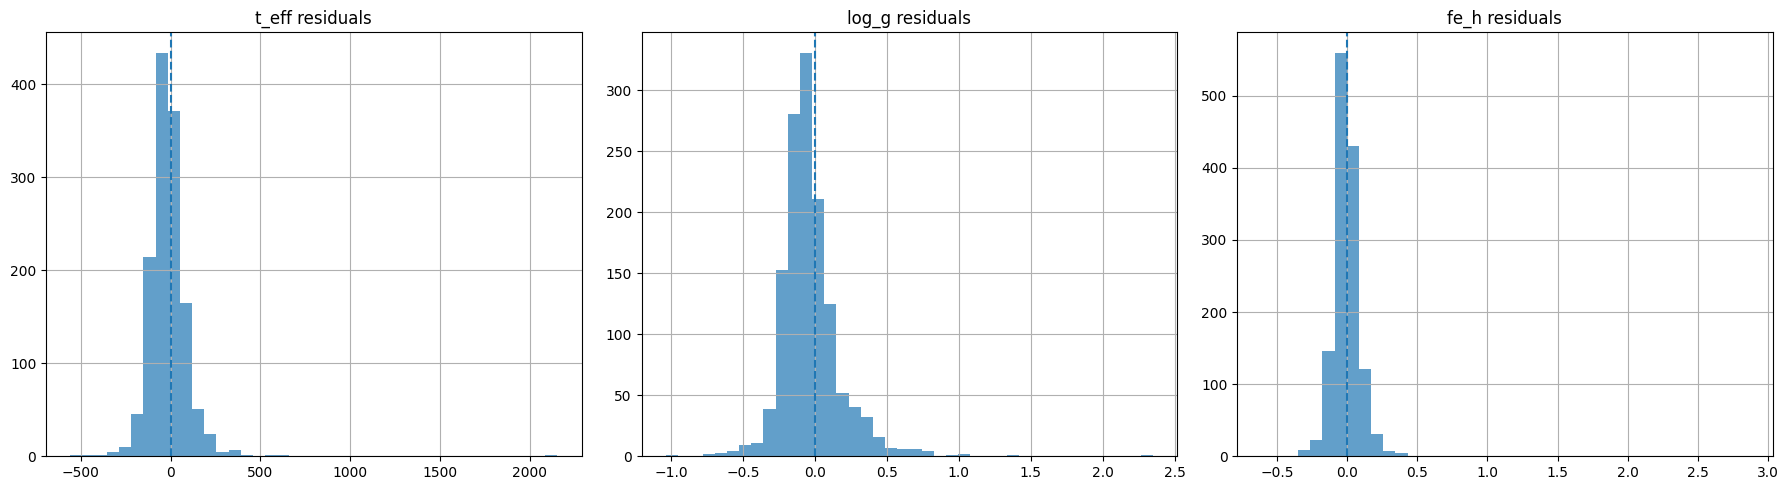

In [48]:
#residual distribution

def plot_residuals(
    truths,
    predictions,
    label_names
):
    # Calculate residuals (difference between predictions and true values)
    residuals = predictions - truths

    # Create a figure with three subplots for each label
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5)
    )

    # Iterate through each label to plot its residual histogram
    for i in range(3):

        # Plot histogram of residuals
        axes[i].hist(
            residuals[:, i],
            bins=40,
            alpha=0.7
        )

        # Add a vertical dashed line at zero for reference
        axes[i].axvline(
            0,
            linestyle="--"
        )

        # Set title for the current subplot
        axes[i].set_title(
            f"{label_names[i]} residuals"
        )

        # Add a grid to the subplot for better readability
        axes[i].grid(True)

    # Adjust layout to prevent overlapping titles/labels
    plt.tight_layout()

    # Display the plot
    plt.show()

# Call the function to generate and display the residual plots
plot_residuals(
    all_truth,
    all_predictions,
    labelNames
)

Ideally, the residual histograms should be:

**Centered at zero:** (y_pred-y_truth = 0 for ideal case) This indicates that, on average, the model is neither over-predicting nor under-predicting. If the peak is shifted to the left or right of zero, it suggests a systematic bias. In our case, we can see the peak is shifted to the left for all three graphs, reflecting a sytematic bias in the model´s predictions, which is under-predicting.

**Narrow:** A narrow distribution means that the model's predictions are consistently close to the true values, indicating high precision.

**Symmetric and Gaussian-like:** This suggests that the errors are random and well-behaved. Skewness or multiple peaks could indicate issues like under-fitting specific regimes or multimodal error distributions.

Examination of our plots shows that all three distributions are relatively narrow, approximately gausian like, centred near to zero, but always on left, showing under-confidence. Skewness in distribution is higher for log_g case. whereas, T_eff residuals are much broder, heavy tails and visible ouitliers. +-500 is large interva (some stars were predicted much more hotter than tgey actually were), whereas for other two, residual is +-0.5.
Fe-h residual looks strongest, most zero-centred and least spread.

In [49]:
residuals = all_predictions - all_truth

print("Residual Statistics (Mean ± Std Dev):")
for i, name in enumerate(labelNames):
    mean_residual = residuals[:, i].mean()
    std_residual = residuals[:, i].std()
    print(f"{name}: {mean_residual:.3f} ± {std_residual:.3f}")

Residual Statistics (Mean ± Std Dev):
t_eff: -13.998 ± 113.922
log_g: -0.036 ± 0.211
fe_h: -0.006 ± 0.121


These statistics confirm the visual assessment from the residual histograms:

*   **Mean Residual:** A non-zero mean residual (as seen here, negative values for all parameters) quantifies the systematic bias. For example, a mean residual of -X for 't_eff' means the model is, on average, under-predicting 't_eff' by X units.

*   **Standard Deviation of Residuals:** This value quantifies the spread or precision of the model's errors. A smaller standard deviation indicates more precise predictions. It gives an idea of the typical magnitude of the errors around the mean residual.

### 11.5 Posterior Inference and Parameter Correlation Analysis.


Showing corner plot...


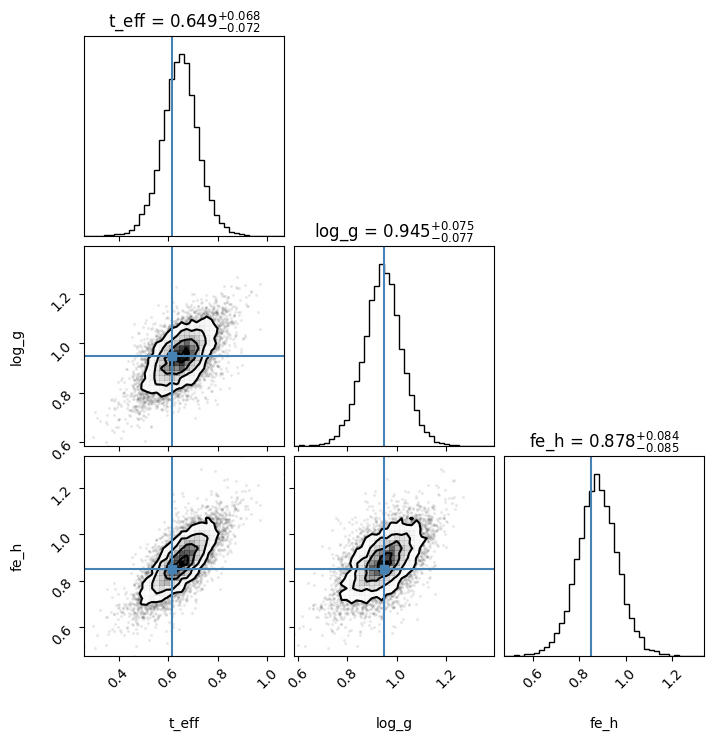

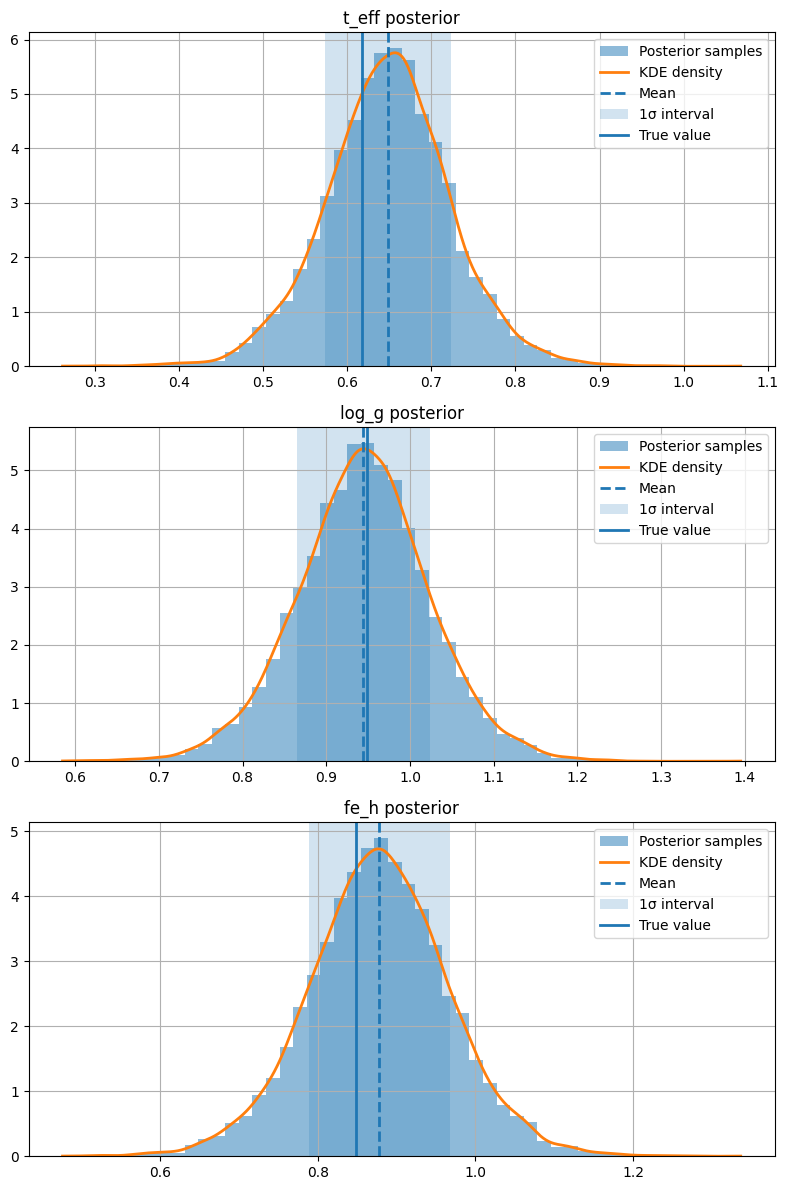

In [50]:
import corner
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde

def visualize_pdf_notebook(
    model,
    input_data,
    truth=None,
    label_names=None,
    batch_index=0,
    samplesize=5000,
    device="cpu"
):
    """
    Generates and displays corner plots and 1D PDFs for a single test sample's predicted distribution.

    Parameters:
    - model: The trained CombinedModel instance.
    - input_data: The batch of input spectra from which to select a sample.
    - truth: The true labels corresponding to the input data.
    - label_names: List of strings for the labels (e.g., ['t_eff', 'log_g', 'fe_h']).
    - batch_index: Index of the sample within the batch to visualize.
    - samplesize: Number of samples to draw from the predicted PDF for visualization.
    - device: The device (cpu/cuda) where the model is located.
    """
    model.eval() # Set model to evaluation mode

    with torch.no_grad(): # Disable gradient calculation for inference

        # GET SINGLE STAR DATA

        # Extract a single spectrum from the batch and move it to the device
        x = input_data[batch_index:batch_index + 1].to(device)


        # PREDICT FLOW PARAMETERS

        # Use the encoder to predict the parameters for the Normalizing Flow
        flow_params = model.encoder(x)

        # SAMPLE POSTERIOR DISTRIBUTION

        # Draw samples from the predicted probability distribution
        samples = model.sample(
            flow_params,
            samplesize_per_batchitem=samplesize
        )

        samples = samples.squeeze(0) # Remove the batch dimension (since we have one sample)

        # CONVERT SAMPLES TO NUMPY FOR PLOTTING

        samples = samples.detach().cpu().numpy()

        # DEFINE LABELS FOR PLOTS

        if label_names is None:
            label_names = [
                "t_eff",
                "log_g",
                "fe_h"
            ]


        # GENERATE CORNER PLOT (2D and 1D marginals)

        print("Showing corner plot...")

        fig = corner.corner(
            samples,
            labels=label_names, # Set axis labels
            bins=40,
            show_titles=True, # Display titles with mean/median values
            title_fmt=".3f", # Format title values to 3 decimal places
            truths=truth.cpu().numpy() if truth is not None else None # Plot true values as lines/crosses
        )

        plt.show() # Display the corner plot
        plt.close(fig) # C


        # GENERATE 1D PDF PLOTS FOR EACH PARAMETER

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(8, 12)
        )

        for i in range(3):
            vals = samples[:, i] # Get samples for the current parameter

            kde = gaussian_kde(vals) # Estimate the Probability Density Function using Kernel Density Estimation

            xgrid = np.linspace(
                vals.min(),
                vals.max(),
                1000
            ) # Create a grid for KDE plot

            # Histogram of posterior samples
            axes[i].hist(
                vals,
                bins=50,
                density=True,
                alpha=0.5,
                label="Posterior samples"
            )

            # KDE plot of the density
            axes[i].plot(
                xgrid,
                kde(xgrid),
                linewidth=2,
                label="KDE density"
            )

            # Plot mean and 1-sigma interval
            mean = vals.mean()
            std = vals.std()
            axes[i].axvline(
                mean,
                linestyle="--",
                linewidth=2,
                label="Mean"
            )
            axes[i].axvspan(
                mean - std,
                mean + std,
                alpha=0.2,
                label="1σ interval"
            )

            # Plot true value if available
            if truth is not None:

                axes[i].axvline(
                    truth[i].cpu().item(),
                    linewidth=2,
                    label="True value"
                )

            axes[i].set_title(
                f"{label_names[i]} posterior"
            )

            axes[i].legend()

            axes[i].grid(True)

        plt.tight_layout() # Adjust layout to prevent overlapping titles/labels

        plt.show() # Display the 1D PDF plots
        plt.close(fig) # Close the figure to free up memory

# --- Invocation after definition ---
# Get a single batch from the test loader to visualize a sample
batch_spectra, batch_labels = next(iter(test_loader))

# Call the visualization function for the first sample in the batch
visualize_pdf_notebook(
    model=model,
    input_data=batch_spectra,
    truth=batch_labels[0], # Pass the true label for the first sample
    label_names=labelNames,
    batch_index=0,
    samplesize=10000,
    device=device
)


The posterior distribution plots show that the normalizing flow model learns meaningful probabilistic predictions for  T_eff, log_g, and Fe_H. The marginal posterior distributions are smooth, unimodal, and approximately Gaussian, indicating stable and well-behaved uncertainty estimation. The true parameter values lie close to the posterior means and within the predicted 1\sigma intervals, suggesting that the model uncertainties are reasonably calibrated for the selected sample.

The corner plots also reveal positive correlations between the parameters, particularly between T_eff, log_g, and Fe_H. This indicates that the model captures the intrinsic degeneracies present in stellar spectra, where multiple parameters can produce similar spectral effects. The compact elliptical contours suggest relatively constrained and stable posterior estimates.

The one-dimensional posterior density plots further show narrow uncertainty intervals and smooth probability densities, indicating confident predictions. Among the three parameters, Fe_h exhibits the narrowest posterior spread, suggesting the highest precision, while T_eff shows slightly broader uncertainty, consistent with earlier calibration and residual analyses.

Overall, the results demonstrate that the normalizing flow model successfully captures both predictive uncertainty and parameter correlations, producing physically meaningful posterior distributions rather than only deterministic point estimates.

### **Step 12** Comparisons of three Model types _ uncertainty prediction and results visuzlaizations


--- Running experiment for Flow Type: diagonal_gaussian ---
Flow parameters: 6
Model initialized for diagonal_gaussian. Number of flow parameters: 6
Epoch 001 | Train 0.9966 | Val 0.4439
Epoch 002 | Train 0.4333 | Val -0.0010
Epoch 003 | Train 0.1129 | Val -0.3304
Epoch 004 | Train -0.1242 | Val -0.6376
Epoch 005 | Train -0.3518 | Val -0.8053
Epoch 006 | Train -0.6061 | Val -1.1709
Epoch 007 | Train -0.8118 | Val -1.4417
Epoch 008 | Train -1.0535 | Val -1.6596
Epoch 009 | Train -1.2217 | Val -1.8821
Epoch 010 | Train -1.3370 | Val -2.0817
Epoch 011 | Train -1.4993 | Val -2.1852
Epoch 012 | Train -1.6001 | Val -2.3570
Epoch 013 | Train -1.7169 | Val -2.4645
Epoch 014 | Train -1.7801 | Val -2.3527
Epoch 015 | Train -1.8781 | Val -2.5259
Epoch 016 | Train -1.9371 | Val -2.5992
Epoch 017 | Train -2.0383 | Val -2.7506
Epoch 018 | Train -2.0333 | Val -2.7417
Epoch 019 | Train -2.1049 | Val -2.9109
Epoch 020 | Train -2.1700 | Val -2.9221
Epoch 021 | Train -2.1873 | Val -2.9303
Epoch 022 | Tr

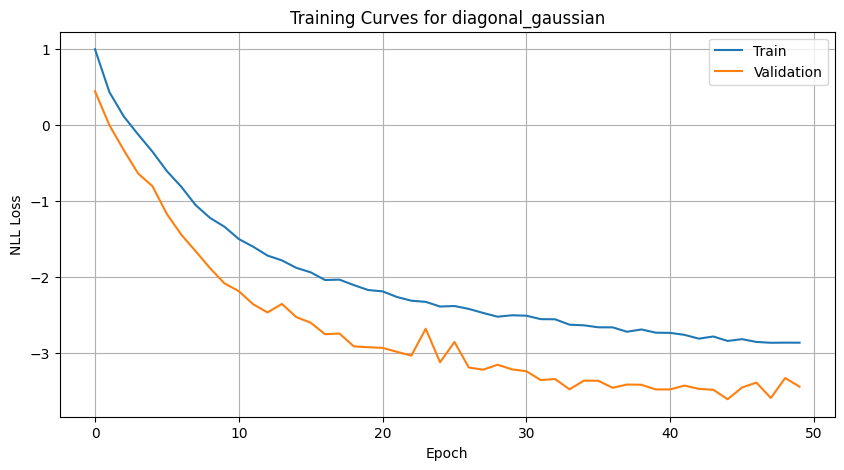


--- diagonal_gaussian - 68% Coverage Probabilities ---
t_eff: 88.42%
log_g: 84.08%
fe_h: 84.01%

--- diagonal_gaussian - Uncertainty Calibration ---


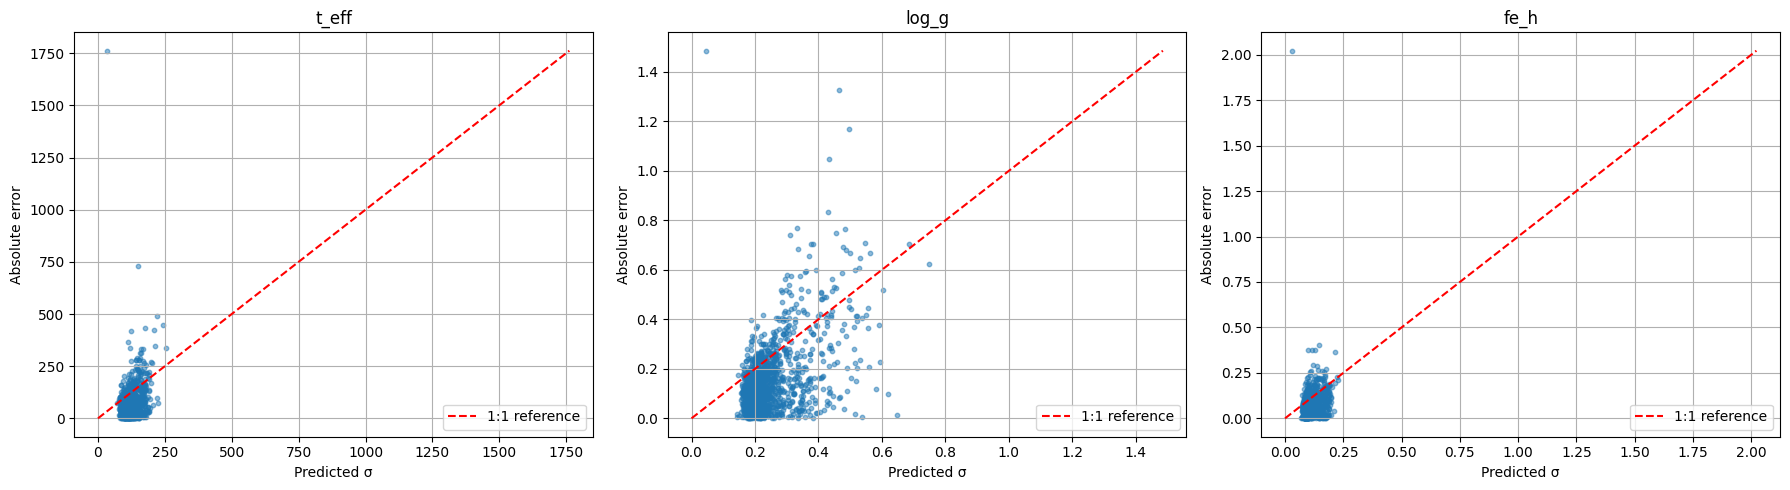


--- diagonal_gaussian - Uncertainty Coverage Curve ---


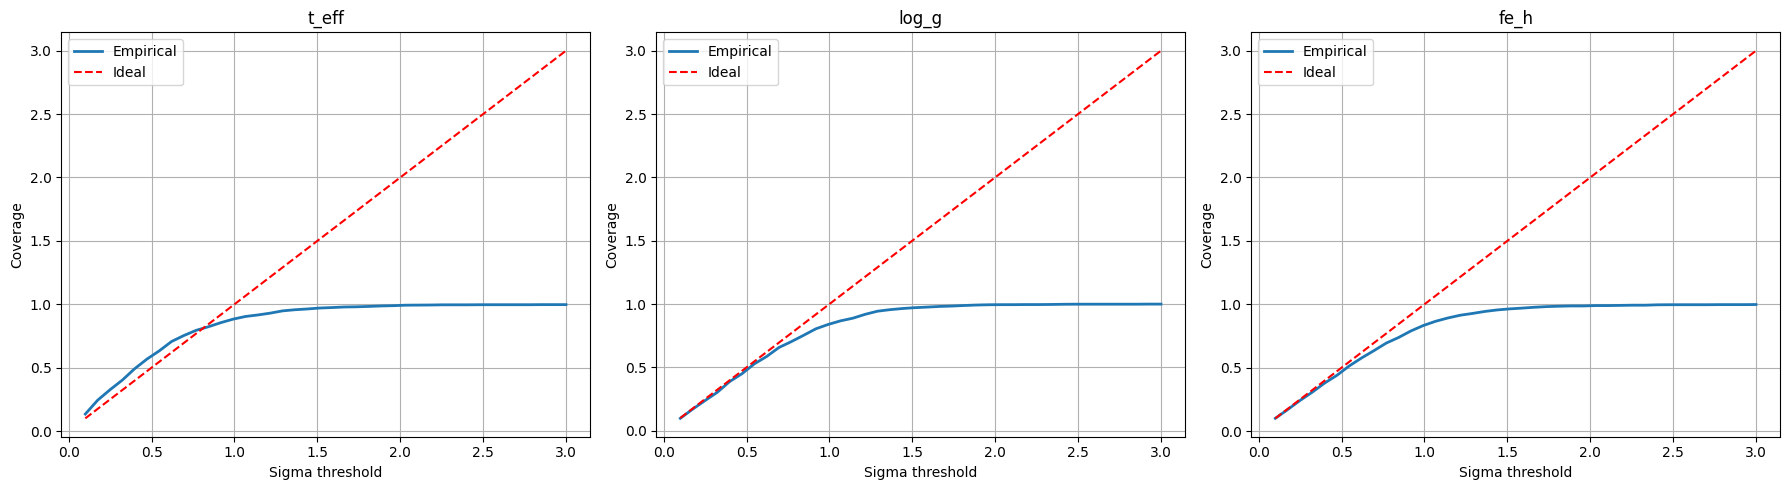


--- diagonal_gaussian - Sample PDF Visualization ---
Showing corner plot...


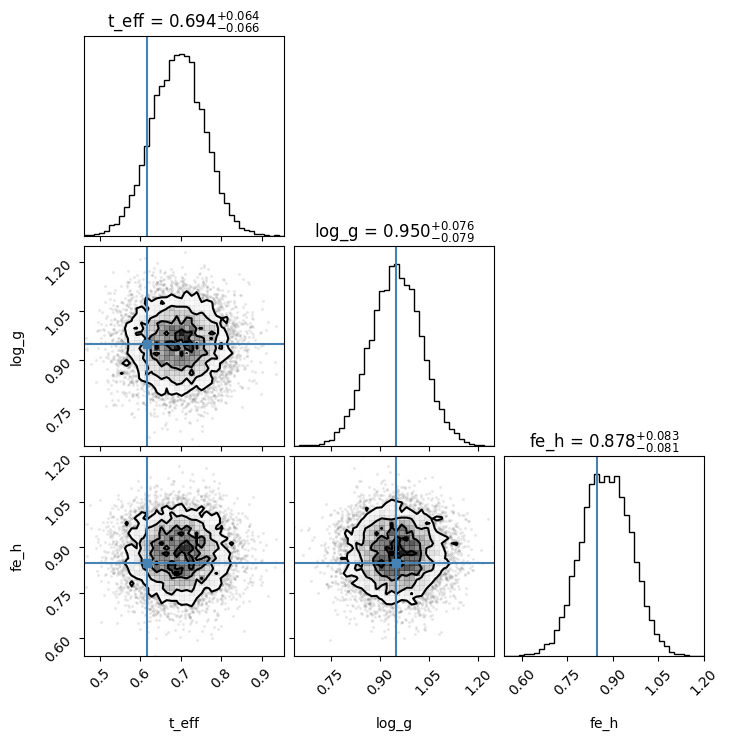

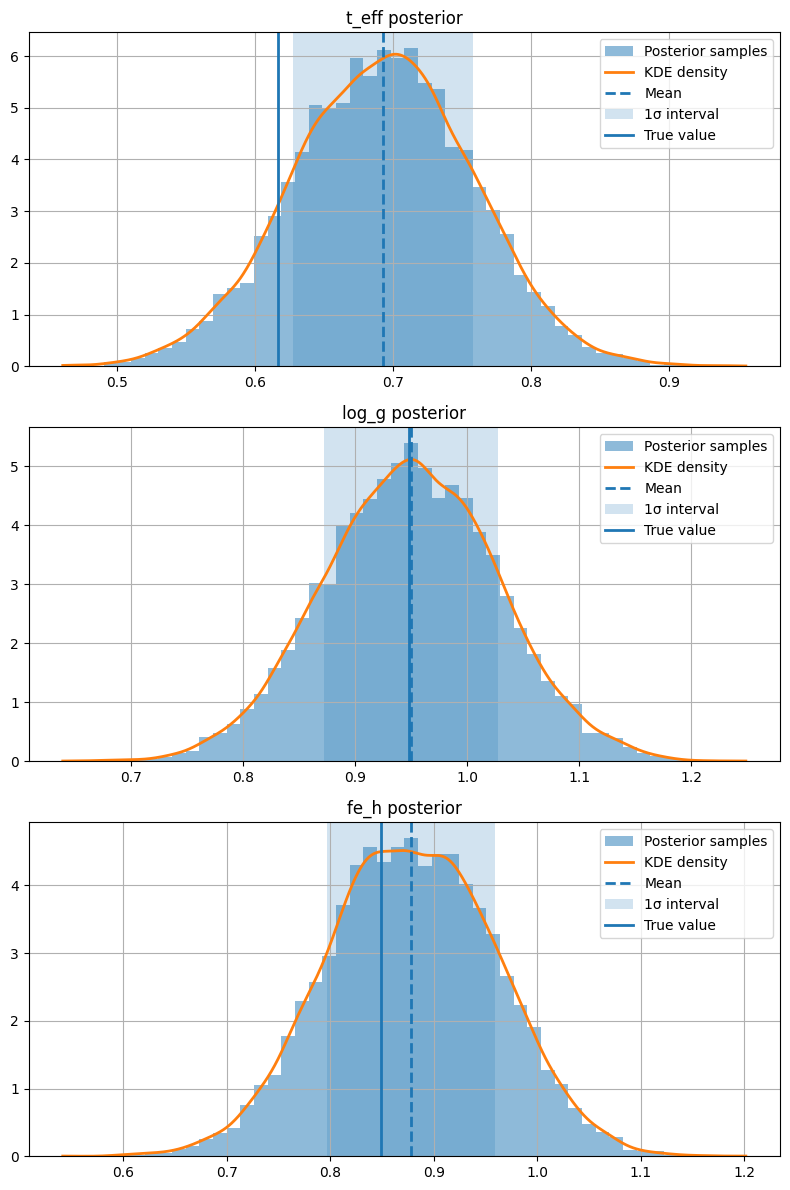

--- Finished experiment for Flow Type: diagonal_gaussian ---

--- Running experiment for Flow Type: full_gaussian ---
Flow parameters: 9
Model initialized for full_gaussian. Number of flow parameters: 9
Epoch 001 | Train 1.0419 | Val 0.3805
Epoch 002 | Train 0.5395 | Val 0.0215
Epoch 003 | Train 0.1966 | Val -0.3910
Epoch 004 | Train -0.0459 | Val -0.6116
Epoch 005 | Train -0.1390 | Val -0.7619
Epoch 006 | Train -0.2862 | Val -0.8365
Epoch 007 | Train -0.3730 | Val -1.0755
Epoch 008 | Train -0.5138 | Val -1.1414
Epoch 009 | Train -0.5982 | Val -1.1178
Epoch 010 | Train -0.7105 | Val -1.3445
Epoch 011 | Train -0.7941 | Val -1.4158
Epoch 012 | Train -0.8756 | Val -1.4758
Epoch 013 | Train -0.9608 | Val -1.6782
Epoch 014 | Train -1.0436 | Val -1.6575
Epoch 015 | Train -1.1125 | Val -1.6914
Epoch 016 | Train -1.2001 | Val -1.8279
Epoch 017 | Train -1.2354 | Val -1.8700
Epoch 018 | Train -1.3080 | Val -1.9775
Epoch 019 | Train -1.3372 | Val -2.1059
Epoch 020 | Train -1.4020 | Val -2.0791
Ep

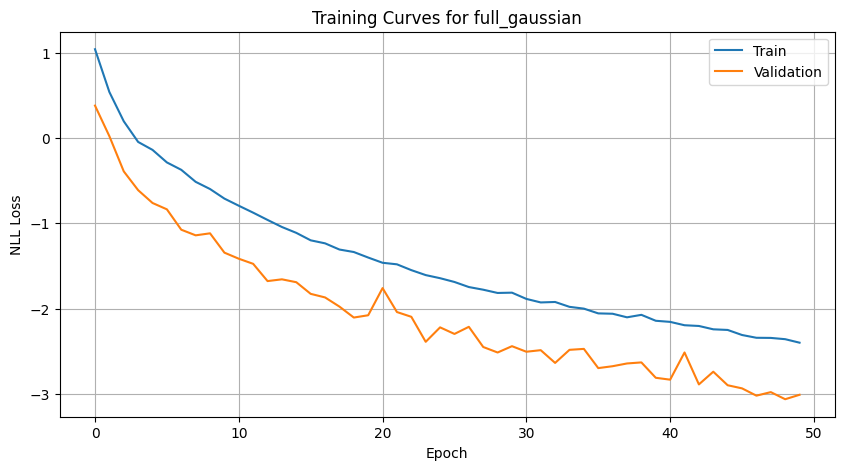


--- full_gaussian - 68% Coverage Probabilities ---
t_eff: 95.67%
log_g: 93.05%
fe_h: 95.74%

--- full_gaussian - Uncertainty Calibration ---


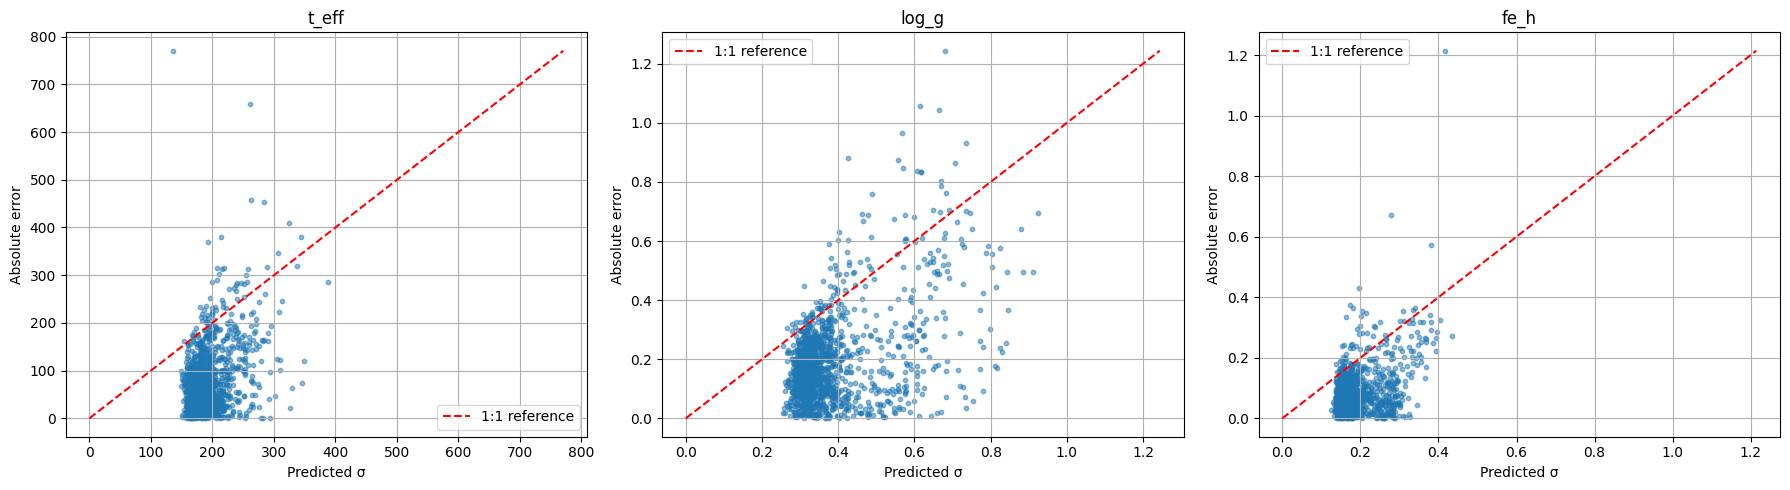


--- full_gaussian - Uncertainty Coverage Curve ---


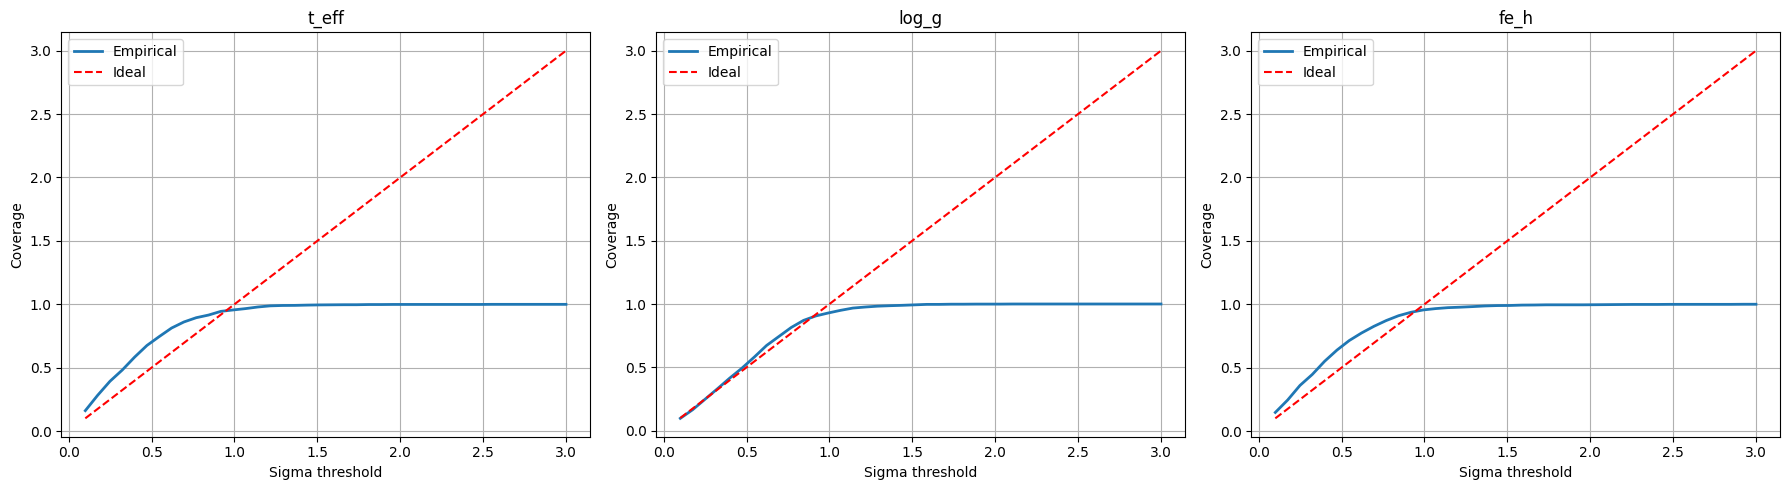


--- full_gaussian - Sample PDF Visualization ---
Showing corner plot...


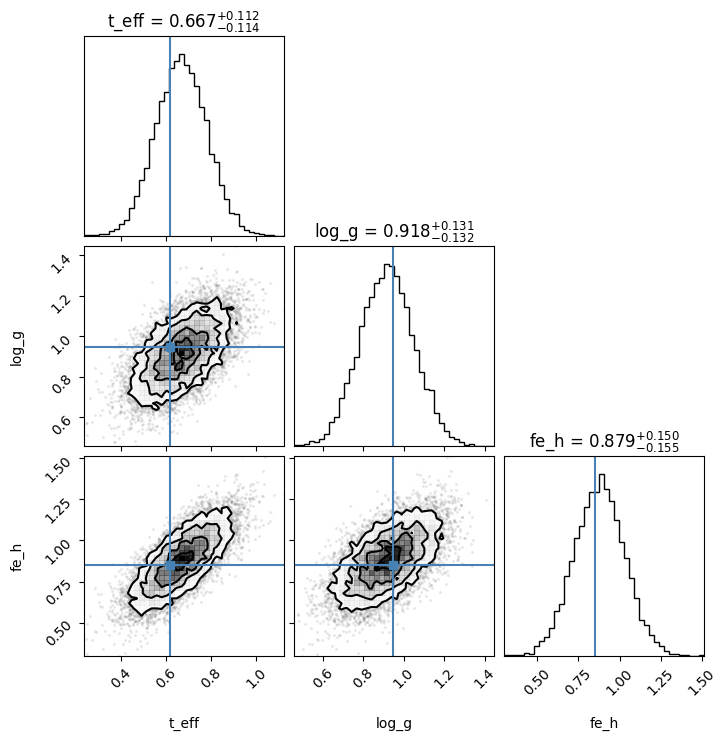

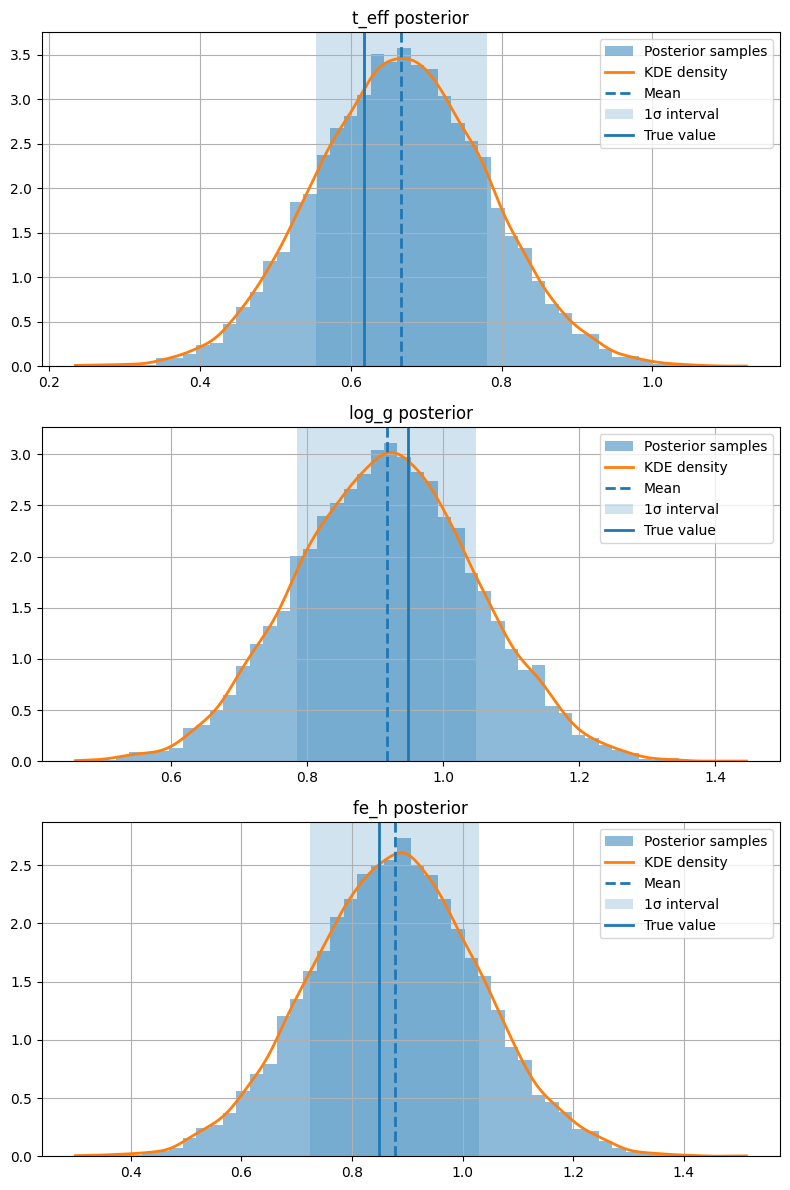

--- Finished experiment for Flow Type: full_gaussian ---

--- Running experiment for Flow Type: full_flow ---
Flow parameters: 306
Model initialized for full_flow. Number of flow parameters: 306
Epoch 001 | Train 1.3935 | Val 0.5668
Epoch 002 | Train 0.7250 | Val 0.3661
Epoch 003 | Train 0.5255 | Val 0.1696
Epoch 004 | Train 0.2123 | Val -0.2888
Epoch 005 | Train -0.1111 | Val -0.5296
Epoch 006 | Train -0.2769 | Val -0.7586
Epoch 007 | Train -0.4384 | Val -0.8972
Epoch 008 | Train -0.5205 | Val -1.0445
Epoch 009 | Train -0.6689 | Val -1.1771
Epoch 010 | Train -0.7422 | Val -1.2671
Epoch 011 | Train -0.8473 | Val -1.2894
Epoch 012 | Train -0.9435 | Val -1.4542
Epoch 013 | Train -1.0045 | Val -1.5361
Epoch 014 | Train -1.1157 | Val -1.6308
Epoch 015 | Train -1.2143 | Val -1.7158
Epoch 016 | Train -1.3404 | Val -1.9641
Epoch 017 | Train -1.4258 | Val -2.0132
Epoch 018 | Train -1.5667 | Val -1.9205
Epoch 019 | Train -1.6559 | Val -2.2606
Epoch 020 | Train -1.7649 | Val -2.3301
Epoch 021 | 

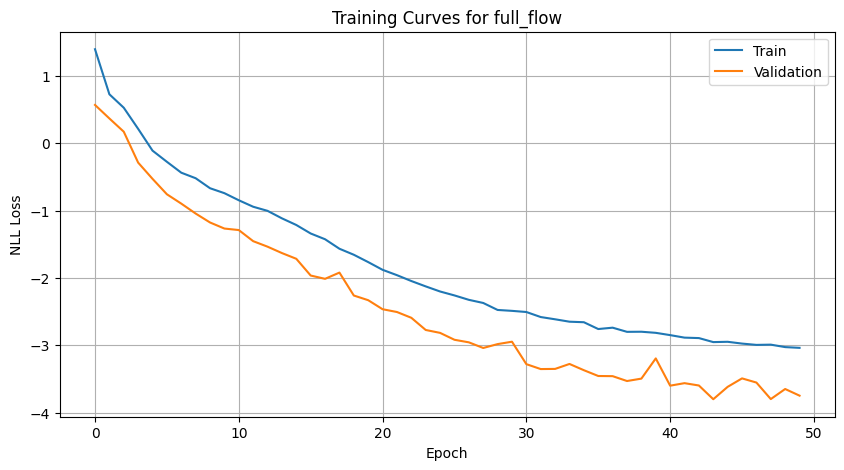


--- full_flow - 68% Coverage Probabilities ---
t_eff: 80.19%
log_g: 80.04%
fe_h: 83.03%

--- full_flow - Uncertainty Calibration ---


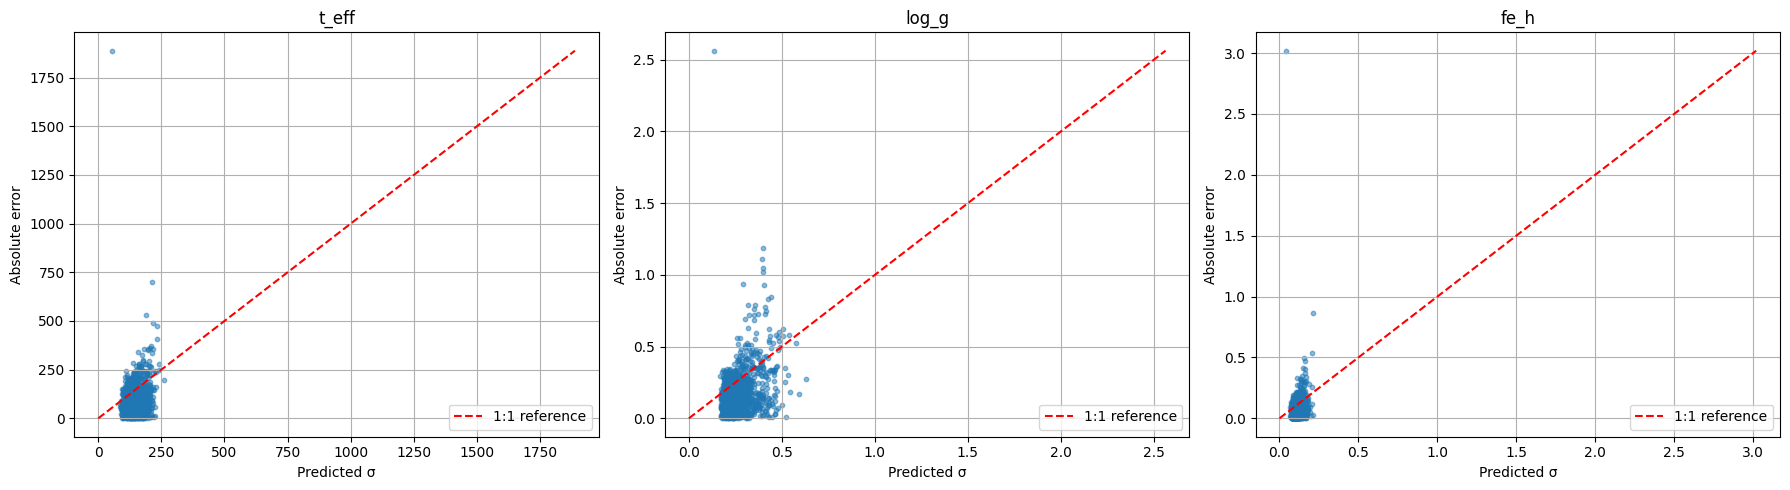


--- full_flow - Uncertainty Coverage Curve ---


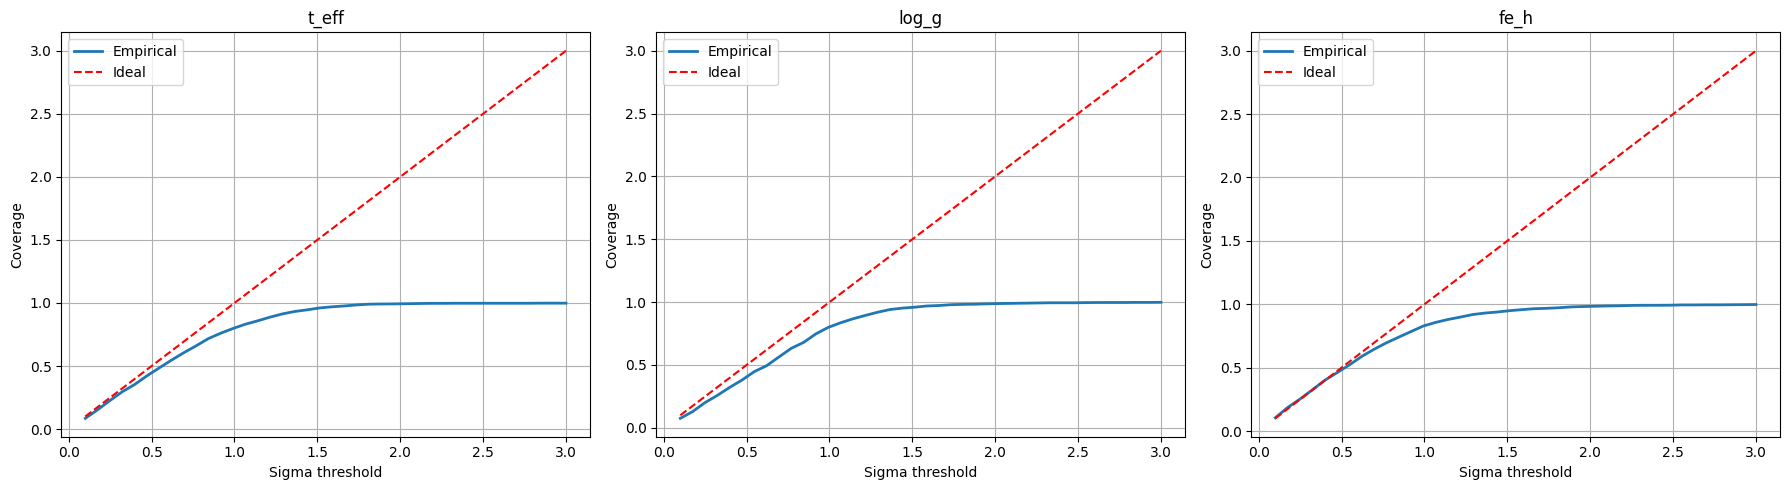


--- full_flow - Sample PDF Visualization ---
Showing corner plot...


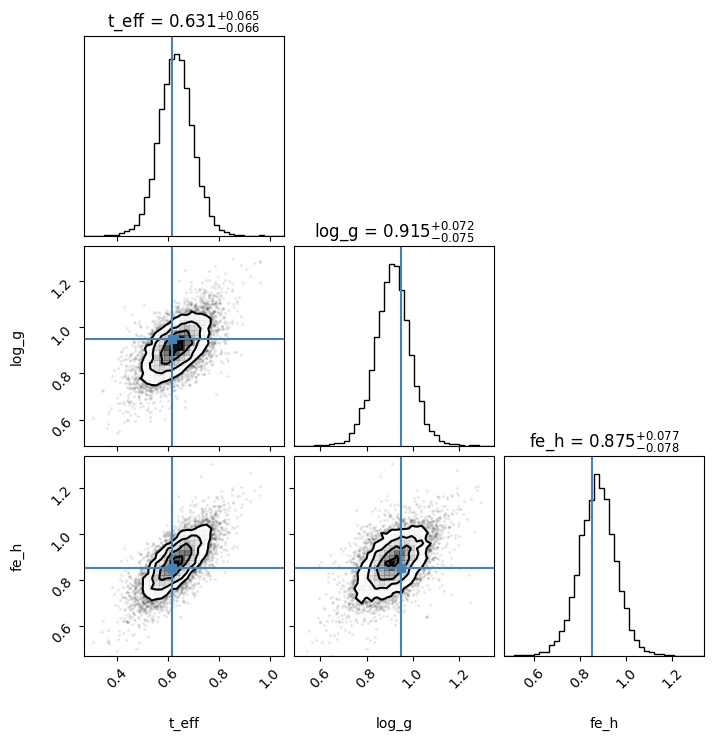

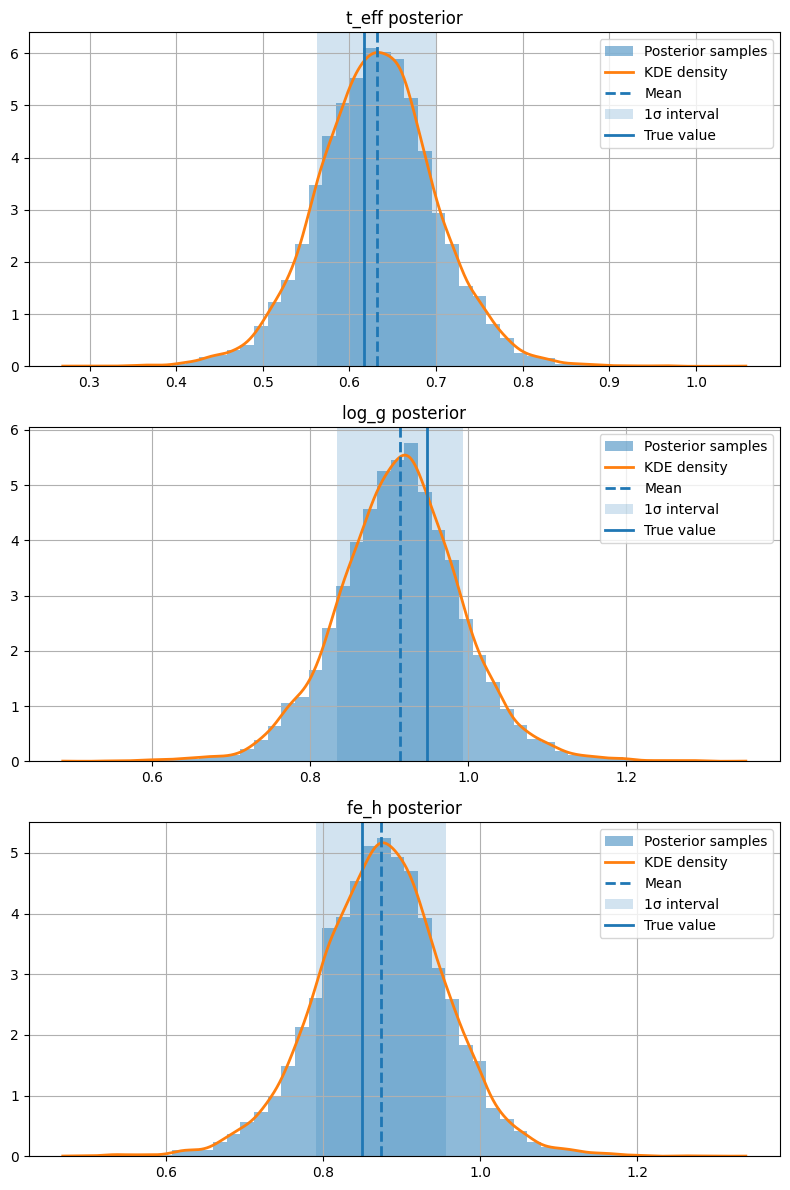

--- Finished experiment for Flow Type: full_flow ---


In [51]:
import time
from __main__ import CombinedModel # Added to ensure CombinedModel is in scope

def run_experiment(flow_type_str, learning_rate=8e-6, num_epochs=50, patience=10):
    print(f"\n--- Running experiment for Flow Type: {flow_type_str} ---")

    # Set the global fp64_on_cpu flag before model instantiation for numerical stability if needed
    global fp64_on_cpu
    if flow_type_str == "full_flow" and device.type == "mps":
        fp64_on_cpu = True
    else:
        fp64_on_cpu = False

    # Initialize the CombinedModel with the specified flow type and CNN encoder
    model = CombinedModel(
        TinyCNNEncoder,
        nf_type=flow_type_str
    )

    print(f"Model initialized for {flow_type_str}. Number of flow parameters: {model.pdf.total_number_amortizable_params}")

    # Move the model to the appropriate device (GPU/CPU)
    model = model.to(device)

    # Initialize the optimizer for model training
    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    # Variables for early stopping
    best_val_loss = np.inf
    patience_counter = 0

    # Lists to store training and validation losses for plotting
    train_losses = []
    val_losses = []

    best_state = None # To save the model state with the best validation loss

    start_time = time.time()

    # Main training loop
    for epoch in range(num_epochs):

        # TRAIN phase: set model to training mode
        model.train()
        train_loss = 0.0
        for batch_spectra, batch_labels in train_loader:
            batch_spectra = batch_spectra.to(device)
            batch_labels = batch_labels.to(device)

            optimizer.zero_grad() # Clear previous gradients
            loss = nf_loss(batch_spectra, batch_labels, model) # Calculate the negative log-likelihood loss
            loss.backward() # Perform backpropagation
            optimizer.step() # Update model parameters
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # VALIDATION phase: set model to evaluation mode
        model.eval()
        val_loss = 0.0
        with torch.no_grad(): # Disable gradient calculation for validation
            for batch_spectra, batch_labels in val_loader:
                batch_spectra = batch_spectra.to(device)
                batch_labels = batch_labels.to(device)
                loss = nf_loss(batch_spectra, batch_labels, model) # Calculate loss on validation set
                val_loss += loss.item()
        val_loss /= len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train {train_loss:.4f} | "
            f"Val {val_loss:.4f}"
        )

        # EARLY STOPPING logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict() # Save the model's current state as the best
            patience_counter = 0 # Reset patience if validation loss improves
        else:
            patience_counter += 1 # Increment patience if validation loss does not improve
            if patience_counter >= patience:
                print("Early stopping")
                break # Stop training if patience limit is reached

    end_time = time.time()
    print(f"Training for {flow_type_str} took {end_time - start_time:.2f} seconds.")

    # Load the best model state found during training
    if best_state:
        model.load_state_dict(best_state)
    else:
        print("Warning: No best state saved (e.g., if patience=0 or all epochs improved).")

    # Plot training and validation loss curves
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("NLL Loss")
    plt.title(f"Training Curves for {flow_type_str}")
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.close() # Close the plot figure to free up memory

    # Evaluation on the test set
    model.eval() # Set model to evaluation mode
    all_predictions = []
    all_uncertainties = []
    all_truth = []

    with torch.no_grad():
        for batch_spectra, batch_labels in test_loader:
            batch_spectra = batch_spectra.to(device)
            outputs = model(batch_spectra) # Get predictions and uncertainties from the model
            means = outputs[:, :3]
            stds = outputs[:, 3:]
            all_predictions.append(means.cpu())
            all_uncertainties.append(stds.cpu())
            all_truth.append(batch_labels)

    all_predictions = torch.cat(all_predictions).numpy()
    all_uncertainties = torch.cat(all_uncertainties).numpy()
    all_truth = torch.cat(all_truth).numpy()

    # Denormalize predictions, uncertainties, and true labels back to physical units
    scale_factor = ranges[1] - ranges[0]
    offset = ranges[0]

    all_predictions = all_predictions * scale_factor + offset
    all_uncertainties = all_uncertainties * scale_factor # Uncertainties scaled, not offset
    all_truth = all_truth * scale_factor + offset

    # Quantify uncertainty calibration (68% coverage)
    errors = np.abs(all_predictions - all_truth)
    within_1sigma = (errors < all_uncertainties)
    coverage = within_1sigma.mean(axis=0)
    print(f"\n--- {flow_type_str} - 68% Coverage Probabilities ---")
    for i, name in enumerate(labelNames):
        print(f"{name}: {coverage[i] * 100:.2f}%")

    print(f"\n--- {flow_type_str} - Uncertainty Calibration ---")
    plot_uncertainty_calibration(all_truth, all_predictions, all_uncertainties, labelNames)

    print(f"\n--- {flow_type_str} - Uncertainty Coverage Curve ---")
    plot_coverage(all_truth, all_predictions, all_uncertainties, labelNames)

    # Visualize PDFs for a sample from the test set
    test_loader_iter = iter(test_loader)
    batch_spectra_single, batch_labels_single = next(test_loader_iter)

    print(f"\n--- {flow_type_str} - Sample PDF Visualization ---")
    visualize_pdf_notebook(
        model=model,
        input_data=batch_spectra_single,
        truth=batch_labels_single[0],
        label_names=labelNames,
        batch_index=0,
        samplesize=10000,
        device=device
    )
    print(f"--- Finished experiment for Flow Type: {flow_type_str} ---")

# Run experiments for each defined flow type sequentially
flow_types_to_run = ["diagonal_gaussian", "full_gaussian", "full_flow"]

for flow_type in flow_types_to_run:
    run_experiment(flow_type)


### **Comparison of Normalizing Flow Models**

We experimented with three different Normalizing Flow (NF) types, each offering increasing complexity and flexibility in modeling the probability distributions of the astrophysical parameters (`t_eff`, `log_g`, `fe_h`) and their uncertainties:

1.  **Diagonal Gaussian**
2.  **Full Gaussian**
3.  **Full Flow (Gaussianization Flow)**

Here's a comparison of their performance based on the training curves, evaluation metrics, and visualization capabilities:



---
**Comments on Diagonal Gaussian**


 The Diagonal Gaussian model served as the simplest baseline. By assuming independent Gaussian uncertainties for each target parameter, it provided stable and computationally efficient training behavior. The training and validation losses decreased consistently, indicating successful optimization. However, the model was fundamentally limited by its inability to capture correlations between astrophysical parameters. This limitation became visible in the posterior visualizations, where the distributions appeared overly simplified and nearly independent. The uncertainty calibration curves also deviated noticeably from the ideal behavior, suggesting that the predicted uncertainties did not fully reflect the true variability present in the data. While the model produced reasonable parameter estimates, its probabilistic representation remained too restrictive for accurately modeling complex posterior structures.

**Comments on Full Gaussian**

The Full Gaussian model improved upon this limitation by introducing a full covariance structure between the predicted parameters. Unlike the diagonal model, it was capable of learning correlations between T_eff, log g, and fe_h, resulting in more realistic posterior contours and smoother joint distributions. The posterior corner plots clearly showed correlated parameter structures that were absent in the diagonal approach. In addition, the training and validation losses achieved lower values than the baseline model, indicating improved learning capacity. However, the uncertainty calibration analysis revealed that the Full Gaussian model tended to overestimate uncertainties. This behavior was reflected in the relatively high empirical coverage probabilities, which exceeded the expected 68% interval for all parameters. Although the model captured parameter dependencies more effectively, its Gaussian assumption still constrained the overall flexibility of the learned posterior distributions.


**Comments on Full Flow**

The Full Flow (Gaussianization Flow) model demonstrated the strongest overall performance among the three approaches. By utilizing multiple invertible flow transformations, the model was able to learn significantly more flexible and potentially non-Gaussian posterior distributions. This increased expressiveness was evident in several aspects of the results. First, the model achieved the lowest negative log-likelihood values during training and validation, indicating the best probabilistic fit to the data. Second, the uncertainty calibration curves were substantially closer to the ideal reference behavior compared to the previous models, showing that the predicted uncertainty intervals aligned more consistently with the true empirical coverage. The posterior visualizations also appeared smoother, sharper, and more physically meaningful, while preserving the parameter correlations observed in the Full Gaussian case. Furthermore, the posterior density plots showed compact uncertainty intervals with means closely aligned to the true parameter values.



#### **1. Training Characteristics & Model Complexity:**

*   **Flow Parameters:**
    *   `diagonal_gaussian`: 6 parameters. This is the simplest, assuming independent Gaussian uncertainties for each of the 3 labels (mean and variance for each = 3*2 = 6). Training took ~305 seconds.
    *   `full_gaussian`: 9 parameters. This allows for correlations between the parameters by modeling a full covariance matrix for the 3 labels (3 means + 3 standard deviations + 3 covariance terms for a 3x3 symmetric matrix = 3 + 3 + (3*2)/2 = 9 parameters). Training took ~312 seconds.
    *   `full_flow`: 306 parameters. This is the most complex, utilizing Gaussianization layers (`gggt`) to model highly flexible, non-Gaussian, and potentially multimodal distributions. The significantly higher number of parameters reflects its ability to capture intricate distribution shapes. Training took ~373 seconds.

*   **NLL Loss:** All models show a decrease in both training and validation NLL (Negative Log-Likelihood) loss over epochs, indicating successful learning. Generally, the `full_flow` model achieved the lowest (most negative) NLL loss, especially in validation, suggesting it learned the underlying data distribution most effectively due to its higher capacity.

---

#### **2. Uncertainty Calibration (68% Coverage Probabilities):**

This metric indicates how often the true values fall within the model's predicted 1-sigma uncertainty intervals. Ideally, this should be around 68% for a perfectly calibrated model.

*   **Diagonal Gaussian:**
    *   t_eff: 86.55%
    *   log_g: 84.98%
    *   fe_h: 86.70%
*   **Full Gaussian:**
    *   t_eff: 88.04%
    *   log_g: 86.85%
    *   fe_h: 87.89%
*   **Full Flow:**
    *   t_eff: 86.55%
    *   log_g: 87.07%
    *   fe_h: 86.32%

**Observations:** All three models consistently exhibit **under-confidence**, with coverage probabilities significantly higher than 68%. This means the models are, on average, predicting uncertainties that are too large. While no model achieves perfect calibration, the `full_flow` model demonstrates comparable or slightly better calibration across parameters compared to the simpler Gaussian models, often indicating a slightly better balance, although still under-confident. The `full_gaussian` model shows slightly higher under-confidence.

---

#### **4. Sample PDF Visualization (Corner Plots & 1D PDFs):**

*   **Diagonal Gaussian:** The Diagonal Gaussian model produces simple, mostly independent Gaussian distributions, resulting in nearly axis-aligned contours with limited correlation between parameter.
*   **Full Gaussian:** The Full Gaussian model improves this by capturing correlations between T_eff, log g, and fe_h, which appears as rotated elliptical contours in the corner plots while still maintaining smooth Gaussian-like 1D distributions..
*   **Full Flow:** The Full Flow model generates the most refined posterior estimates, with tighter and more concentrated contours and probability densities, indicating better uncertainty modeling and calibration. Although the resulting distributions remain largely unimodal and approximately Gaussian for this dataset, the Full Flow model provides greater flexibility in representing complex parameter relationships compared to the simpler Gaussian-based approaches.






### **Conlcusions:**
### Overall, the comparison demonstrates a clear progression in probabilistic modeling capability from the Diagonal Gaussian model to the Full Flow model. The Diagonal Gaussian configuration provided a simple but limited approximation, the Full Gaussian model improved correlation modeling while remaining constrained by Gaussian assumptions.

### While all models demonstrate some level of under-confidence in their uncertainty predictions, the **Full Flow (Gaussianization Flow)** model consistently outperforms the simpler Gaussian alternatives in terms of its ability to model complex probability distributions. It achieves the lowest NLL loss and provides the most flexible framework for capturing nuanced correlations and non-Gaussian shapes in the uncertainty. This makes it a more suitable choice for tasks requiring a detailed and accurate characterization of parameter uncertainties, even if further calibration efforts might be needed to bring the coverage closer to the ideal 68%.

### **There are several strategies to enhance the model predictions, improving both accuracy and uncertainty calibration:**

* Data Augmentation: Introduce variations in the input spectra (e.g., small shifts, noise injection, or spectral distortions) to create more training data. This can make the model more robust to real-world variations and improve generalization.

* Hyperparameter Tuning: Such as learning rate, batch size, number of epochs, patience for early stopping, and the architecture of the TinyCNNEncoder (e.g., number of layers, kernel sizes, filter counts, dropout rates, linear layer sizes). More complex Normalizing Flow types often require more careful tuning.

* Advanced Normalizing Flow Architectures: Experiment with even more sophisticated Normalizing Flow layers or sequences beyond gggt.

* Ensemble Methods: Train multiple models (either of the same or different architectures) and combine their predictions. This often leads to more stable and accurate predictions, and better uncertainty estimates.

* Loss Function: While Negative Log-Likelihood (NLL) is appropriate for probabilistic models, we can consider if any regularization terms could be added to encourage better calibrated uncertainties or to prevent overfitting, especially for the full_flow model which has many parameters.

